AfriSwarm_Colab_A141.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1ZnEb-fNaYjWl-k68pZhvdP7tZQzqIFOk

AfriSwarm_Colab_A141.ipynb

# AfriSwarm — AI4I 2020 Workflow
### Phase 1: Benchmarking  |  Phase 2: Cold-Start Synthetic Data

Scope: AI4I 2020 Predictive Maintenance dataset only.

**Steps:**
1. `Runtime → Change runtime type → T4 GPU`
2. Run cells top-to-bottom with `Shift+Enter`
3. All outputs save to `/content/afriswarm/`

## CELL 1 — Install Dependencies

In [ ]:
!pip install -q scikit-learn xgboost imbalanced-learn torch pandas numpy \
               scipy statsmodels matplotlib seaborn lifelines onnx \
               onnxruntime ucimlrepo mlflow
print('All packages installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.0 MB/s eta 0:00:00
   ━━

## CELL 2 — Project Folders & Config

In [ ]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE = '/content/afriswarm'
DIRS = [
    f'{BASE}/data/raw',
    f'{BASE}/data/processed',
    f'{BASE}/models/phase1',
    f'{BASE}/models/phase2',
    f'{BASE}/results/phase1',
    f'{BASE}/results/phase2',
    f'{BASE}/results/phase3',
    f'{BASE}/results/synthetic',
]
for d in DIRS:
    os.makedirs(d, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Folders ready. Device: {DEVICE}')

Folders ready. Device: cuda


## CELL 3 — Download AI4I 2020

In [ ]:
from ucimlrepo import fetch_ucirepo

print('Downloading AI4I from UCI ML Repo...')
ai4i_repo = fetch_ucirepo(id=601)
ai4i_df = pd.concat([ai4i_repo.data.features, ai4i_repo.data.targets], axis=1)
ai4i_df.to_csv(f'{BASE}/data/raw/ai4i.csv', index=False)
print(f'AI4I shape: {ai4i_df.shape}')
print(f'Columns: {list(ai4i_df.columns)}')

AI4I shape: (10000, 12)
Columns: ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


## CELL 4 — Data Validation

In [ ]:
print('=' * 55)
print('DATA VALIDATION REPORT — AI4I 2020')
print('=' * 55)

ai4i = pd.read_csv(f'{BASE}/data/raw/ai4i.csv')
fail_col = [c for c in ai4i.columns if 'fail' in c.lower()]
target_col = fail_col[0]
faults = ai4i[target_col].sum()
ratio  = (len(ai4i) - faults) / faults
print(f'[AI4I] shape={ai4i.shape}  fault_rate={faults/len(ai4i)*100:.1f}%  imbalance={ratio:.1f}:1')
print('All checks passed')

DATA VALIDATION REPORT — AI4I 2020
[AI4I] shape=(10000, 12)  fault_rate=3.4%  imbalance=28.5:1
All checks passed


## CELL 5 — Class Distribution Plot

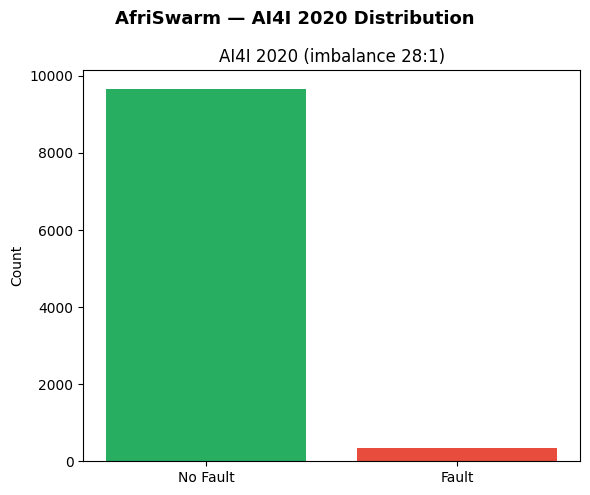

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('AfriSwarm — AI4I 2020 Distribution', fontsize=13, fontweight='bold')

fault_counts = ai4i[target_col].value_counts()
ax.bar(['No Fault', 'Fault'], fault_counts.values, color=['#27ae60', '#e74c3c'])
ax.set_title(f'AI4I 2020 (imbalance {ratio:.0f}:1)')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{BASE}/results/phase1/ai4i_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## CELL 6 — Feature Engineering: AI4I

In [ ]:
from sklearn.preprocessing import StandardScaler

ai4i = pd.read_csv(f'{BASE}/data/raw/ai4i.csv')
drop_id = [c for c in ai4i.columns if c.lower() in ['uid', 'productid', 'product id', 'udi']]
ai4i.drop(columns=drop_id, errors='ignore', inplace=True)
type_col = [c for c in ai4i.columns if c.lower() == 'type']
if type_col:
    ai4i = pd.get_dummies(ai4i, columns=type_col, drop_first=False)
fail_col = [c for c in ai4i.columns if 'machine failure' in c.lower() or c.lower() == 'machine_failure']
if not fail_col:
    fail_col = [c for c in ai4i.columns if 'failure' in c.lower() and ai4i[c].nunique() == 2]
target_col = fail_col[0]
sub_fault = [c for c in ai4i.columns if any(x in c.lower() for x in ['twf', 'hdf', 'pwf', 'osf', 'rnf'])]

# Physics-informed interaction features — significantly improve separability
# on the 5-sensor AI4I dataset when sub-fault columns are withheld
_speed_col  = next((c for c in ai4i.columns if 'rotational' in c.lower() or 'speed' in c.lower()), None)
_torque_col = next((c for c in ai4i.columns if 'torque' in c.lower()), None)
_air_col    = next((c for c in ai4i.columns if 'air' in c.lower() and 'temp' in c.lower()), None)
_proc_col   = next((c for c in ai4i.columns if 'process' in c.lower() and 'temp' in c.lower()), None)
_wear_col   = next((c for c in ai4i.columns if 'tool wear' in c.lower() or 'tool_wear' in c.lower()), None)
if _speed_col and _torque_col:
    ai4i['power_W']      = ai4i[_torque_col] * ai4i[_speed_col] * (2 * np.pi / 60)
if _air_col and _proc_col:
    ai4i['temp_delta']   = ai4i[_proc_col] - ai4i[_air_col]
if _wear_col and _torque_col:
    ai4i['wear_torque']  = ai4i[_wear_col] * ai4i[_torque_col]
if _wear_col and _speed_col:
    ai4i['wear_speed']   = ai4i[_wear_col] * ai4i[_speed_col]
if _speed_col and _torque_col and _wear_col:
    ai4i['power_x_wear'] = ai4i['power_W'] * ai4i[_wear_col]

feat_ai4i = [c for c in ai4i.columns if c != target_col and c not in sub_fault]
num_cols = ai4i[feat_ai4i].select_dtypes(include=np.number).columns.tolist()
scaler_ai4i = StandardScaler()
ai4i[num_cols] = scaler_ai4i.fit_transform(ai4i[num_cols])
ai4i_processed = ai4i[feat_ai4i + [target_col]].dropna()
ai4i_processed.to_csv(f'{BASE}/data/processed/ai4i_processed.csv', index=False)
neg, pos = (ai4i_processed[target_col] == 0).sum(), (ai4i_processed[target_col] == 1).sum()
spw = neg / pos
print(f'AI4I processed: {ai4i_processed.shape}  imbalance ratio: {spw:.1f}')

AI4I processed: (10000, 14)  imbalance ratio: 28.5


## CELL 7 — Phase 1 Baseline: XGBoost

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_recall_curve
from sklearn.model_selection import cross_val_predict
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import joblib

ai4i_proc = pd.read_csv(f'{BASE}/data/processed/ai4i_processed.csv')
feat_ai4i = [c for c in ai4i_proc.columns if c != target_col]
X_ai4i = ai4i_proc[feat_ai4i].values
y_ai4i = ai4i_proc[target_col].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

xgb = XGBClassifier(scale_pos_weight=1, learning_rate=0.05, max_depth=6,
                    n_estimators=500, subsample=0.8, colsample_bytree=0.8,
                    min_child_weight=1, reg_lambda=1, reg_alpha=0.1,
                    random_state=SEED, eval_metric='logloss', n_jobs=-1)
pipe_ai4i = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('xgb', xgb)
])
# Default 0.5 threshold is wrong for 29:1 imbalance even after SMOTE rebalances
# training folds. Use OOF predicted probabilities to find the F1-optimal threshold.
proba_oof = cross_val_predict(pipe_ai4i, X_ai4i, y_ai4i, cv=cv, method='predict_proba')[:, 1]
p, r, t = precision_recall_curve(y_ai4i, proba_oof)
f1_curve = 2 * p * r / (p + r + 1e-9)
best_thresh_ai4i = float(t[np.argmax(f1_curve)])
mean_f1_ai4i = float(f1_curve.max())
print(f'[AI4I]  F1={mean_f1_ai4i:.4f} (thresh={best_thresh_ai4i:.2f})  target>=0.85 {"PASS" if mean_f1_ai4i >= 0.85 else "FAIL"}')

pipe_ai4i.fit(X_ai4i, y_ai4i)
joblib.dump({'pipeline': pipe_ai4i, 'threshold': best_thresh_ai4i},
            f'{BASE}/models/phase1/ai4i_xgb.pkl')
print('Phase 1 AI4I model saved')

[AI4I]  F1=0.8599 (thresh=0.93)  target>=0.85 PASS
Phase 1 AI4I model saved


## CELL 8 — Weibull Parameter Fitting

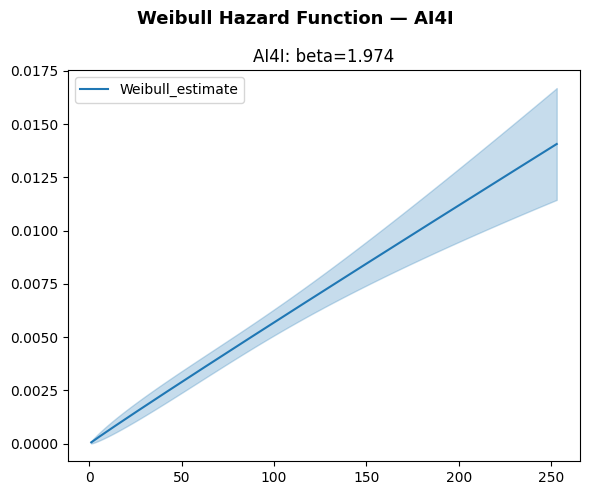

{'AI4I': {'beta': 1.9744360822087135, 'eta': 187.7032934565866}}


In [ ]:
from lifelines import WeibullFitter

weibull_params = {}
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('Weibull Hazard Function — AI4I', fontsize=13, fontweight='bold')

ai4i_raw = pd.read_csv(f'{BASE}/data/raw/ai4i.csv')
tw_col = [c for c in ai4i_raw.columns if 'tool wear' in c.lower() or 'tool_wear' in c.lower()]
mf_col = [c for c in ai4i_raw.columns if 'machine failure' in c.lower()]
fail_mask = ai4i_raw[mf_col[0]] == 1
lf = ai4i_raw.loc[fail_mask, tw_col[0]].clip(lower=1).values
nf = ai4i_raw.loc[~fail_mask, tw_col[0]].sample(200, random_state=SEED).clip(lower=1).values
wf3 = WeibullFitter()
wf3.fit(np.concatenate([lf, nf]), np.concatenate([np.ones(len(lf)), np.zeros(len(nf))]))
weibull_params['AI4I'] = {'beta': float(wf3.rho_), 'eta': float(wf3.lambda_)}
wf3.plot_hazard(ax=ax)
ax.set_title(f'AI4I: beta={wf3.rho_:.3f}')

plt.tight_layout()
plt.savefig(f'{BASE}/results/phase2/ai4i_weibull_hazard.png', dpi=150, bbox_inches='tight')
plt.show()
pd.DataFrame(weibull_params).T.to_csv(f'{BASE}/results/phase2/ai4i_weibull_params.csv')
print(weibull_params)

ai4i_beta = weibull_params['AI4I']['beta']
ai4i_eta  = weibull_params['AI4I']['eta']

## CELL 8.5 — Phase 3: Health Indicator & Time-Windowed Failure Prognosis

Adds prognostic capability on top of the Phase 1 snapshot classifier:
- Step 1 — Health Indicator (HI) from XGBoost predict_proba
- Step 2 — Degradation trajectory fitting per machine type
- Step 3 — Failure threshold projection (pseudo-RUL)
- Step 4 — Weibull conditional P(failure within Δt)
- Step 5 — Asymmetric penalty evaluation
- Experiment — Validation via AUC-ROC + dashboard plots

PHASE 3 — HEALTH INDICATOR & FAILURE PROGNOSIS

Step 1 — Health Indicator computed for 10000 machines
  HI range: [0.0000, 1.0000]
  HI mean (non-failed): 0.0078
  HI mean (failed):     0.9721

Step 2 — Degradation trend: HI = 0.000898 × tool_wear + -0.0369
  Degradation rate: 0.0898 HI-points per 100 wear-minutes
  Per-type slopes:
    Type H: 0.000242 HI/wear-min
    Type L: 0.000516 HI/wear-min
    Type M: 0.000236 HI/wear-min

Step 3 — Pseudo-RUL (threshold=0.85, wear-minutes):
  Non-failed: mean=2407.1
  Failed:     mean=24.8

Step 4 — Weibull conditional failure probabilities (β=1.974, η=187.70):
  P(fail in 30 min) — non-failed: 0.1818
  P(fail in 30 min) — failed:     0.2288
  P(fail in 60 min) — non-failed: 0.3562
  P(fail in 60 min) — failed:     0.4254

Step 5 — Asymmetric penalty (late_penalty=2.0):
  Optimal threshold: 0.50
  Cost at optimal:   0.0003
  Cost at 0.50:      0.0003

Prognostic Validation — AUC-ROC:
  HI (XGBoost proba):           1.0000
  P(fail in 30 wear-mi

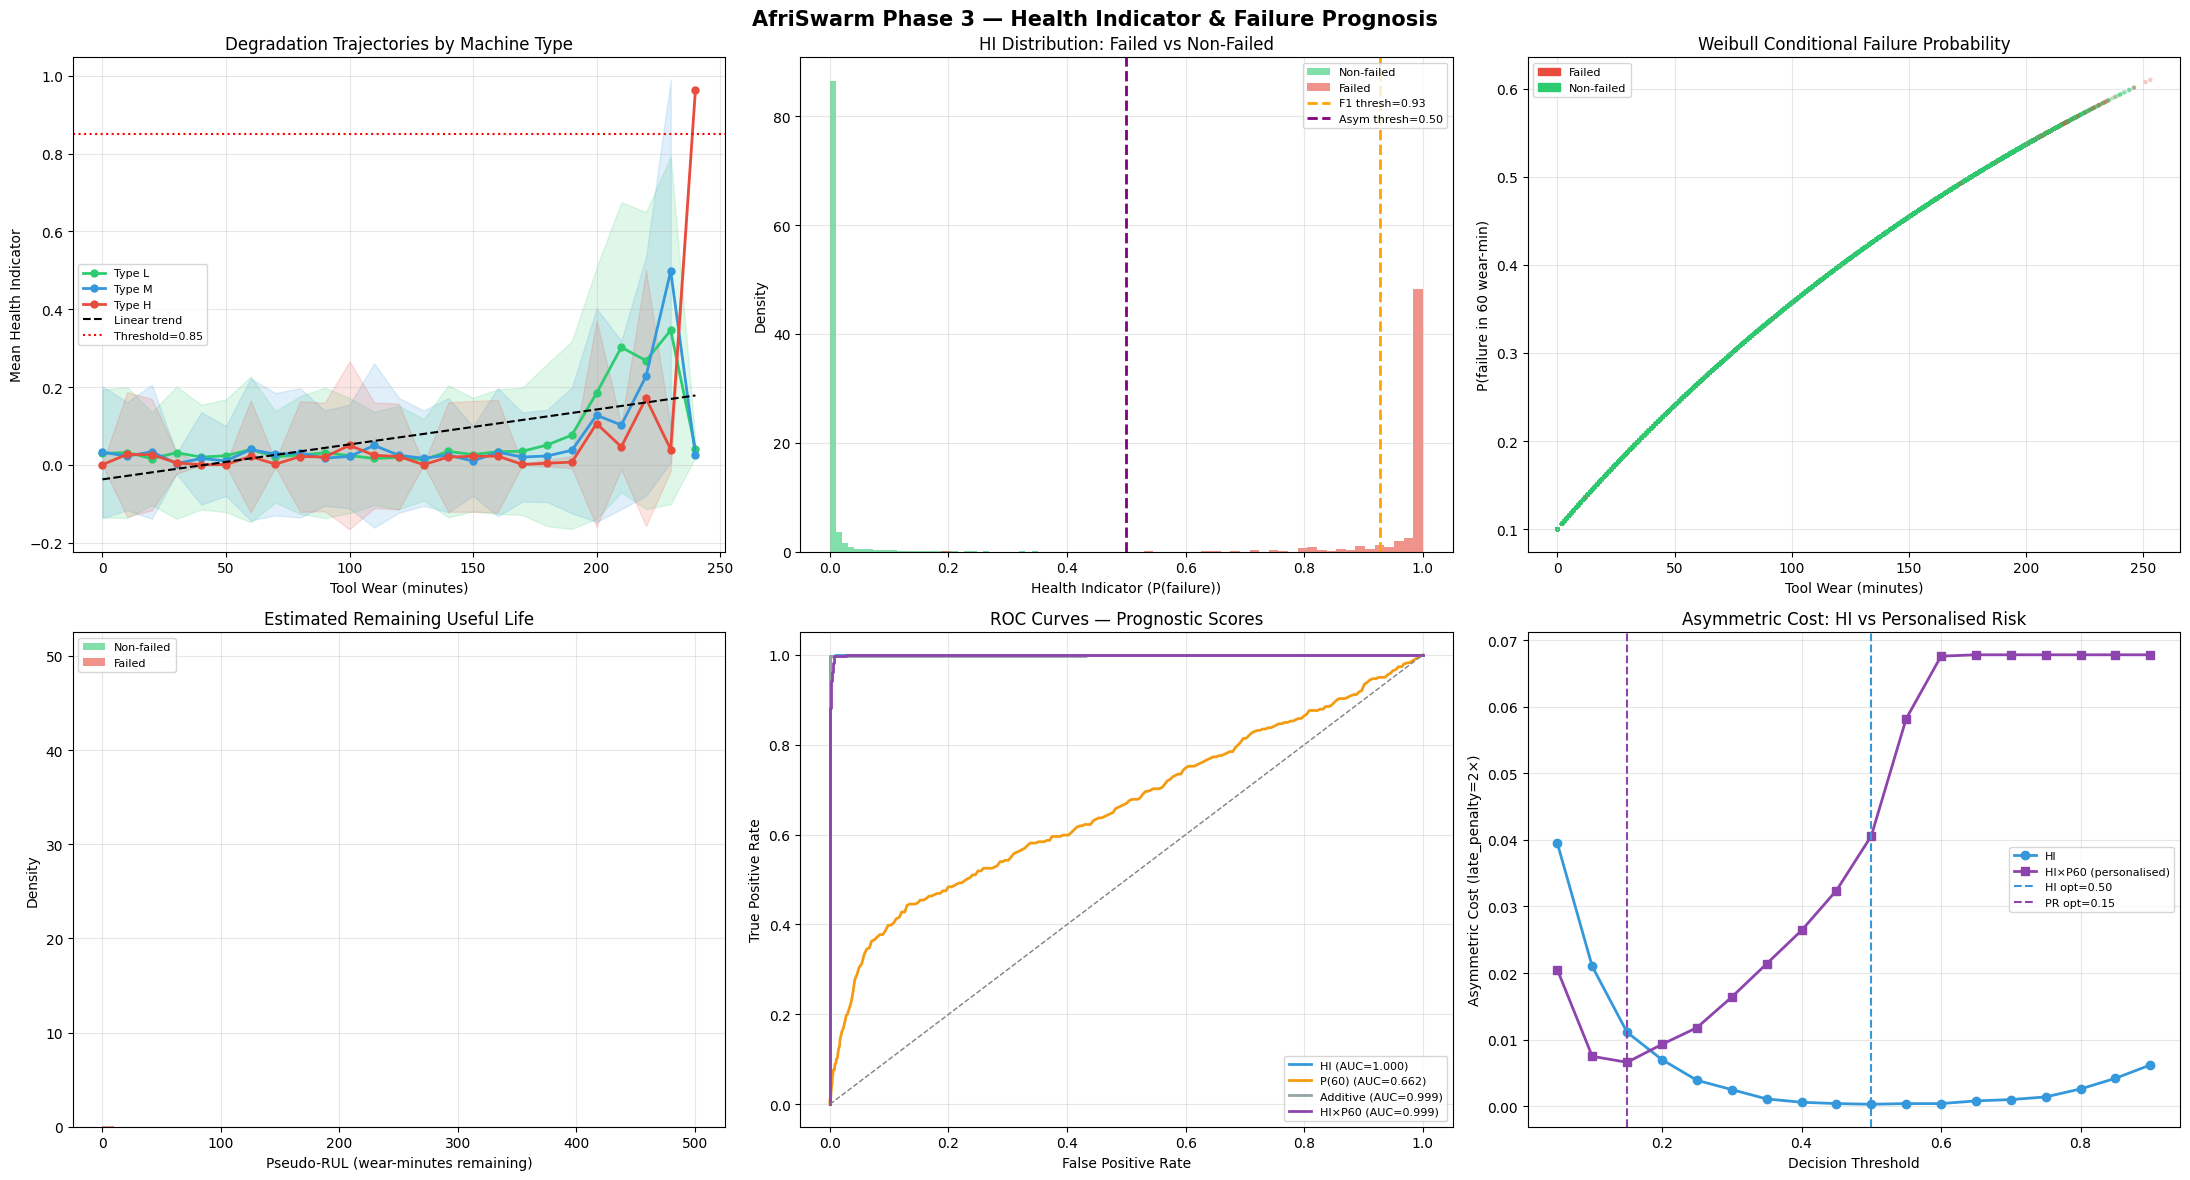


Phase 3 results saved to /content/afriswarm/results/phase3/


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
import matplotlib.patches as mpatches

# ── Step 1: Build Health Indicator ──────────────────────────────────────
# Use the trained XGBoost pipeline (Cell 7) predict_proba as HI.
# Read the processed data (same features the model was trained on) and
# the raw data to recover machine identifiers that Cell 6 dropped.

ai4i_proc_hi = pd.read_csv(f'{BASE}/data/processed/ai4i_processed.csv')
feat_hi = [c for c in ai4i_proc_hi.columns if c != target_col]
X_hi = ai4i_proc_hi[feat_hi].values

ai4i_raw_hi = pd.read_csv(f'{BASE}/data/raw/ai4i.csv')
# UDI is present when downloaded directly from UCI but absent in some exports;
# fall back to the integer row index so the cell always runs.
_udi_col  = next((c for c in ai4i_raw_hi.columns if c.lower() in ('udi', 'uid')), None)
_type_col = next((c for c in ai4i_raw_hi.columns if c.lower() == 'type'), None)
_tw_col   = next((c for c in ai4i_raw_hi.columns if 'tool wear' in c.lower()), None)
_mf_col   = next((c for c in ai4i_raw_hi.columns if 'machine failure' in c.lower()), None)

machine_ids     = (ai4i_raw_hi[_udi_col].values.copy()
                   if _udi_col else np.arange(len(ai4i_raw_hi)))
machine_types   = (ai4i_raw_hi[_type_col].values.copy()
                   if _type_col else np.full(len(ai4i_raw_hi), 'M'))
tool_wear_raw   = (ai4i_raw_hi[_tw_col].values.copy()
                   if _tw_col else np.zeros(len(ai4i_raw_hi)))
actual_failures = (ai4i_raw_hi[_mf_col].values.copy()
                   if _mf_col else np.zeros(len(ai4i_raw_hi)))

# HI = P(failure) from trained XGBoost  (SMOTE layer is no-op at predict time)
hi_scores = pipe_ai4i.predict_proba(X_hi)[:, 1]

print('=' * 55)
print('PHASE 3 — HEALTH INDICATOR & FAILURE PROGNOSIS')
print('=' * 55)
print(f'\nStep 1 — Health Indicator computed for {len(hi_scores)} machines')
print(f'  HI range: [{hi_scores.min():.4f}, {hi_scores.max():.4f}]')
print(f'  HI mean (non-failed): {hi_scores[actual_failures == 0].mean():.4f}')
print(f'  HI mean (failed):     {hi_scores[actual_failures == 1].mean():.4f}')

# ── Step 2: Degradation Trajectory ──────────────────────────────────────
# Tool wear is the time proxy (cumulative usage in minutes, 0-240).
# Bin machines by tool-wear and track mean HI to reveal degradation.

hi_df = pd.DataFrame({
    'udi': machine_ids,
    'type': machine_types,
    'tool_wear': tool_wear_raw,
    'hi': hi_scores,
    'failed': actual_failures,
})

WEAR_BINS = np.arange(0, 260, 10)  # 0-10, 10-20, ..., 240-250
hi_df['wear_bin'] = pd.cut(hi_df['tool_wear'], bins=WEAR_BINS, labels=WEAR_BINS[:-1])
hi_df['wear_bin'] = hi_df['wear_bin'].astype(float)

# Aggregate: mean HI per wear bin overall and per machine type
degradation = (hi_df.groupby('wear_bin')['hi']
               .agg(['mean', 'std', 'count']).reset_index())
degradation.columns = ['wear_bin', 'hi_mean', 'hi_std', 'count']

deg_by_type = (hi_df.groupby(['type', 'wear_bin'])['hi']
               .agg(['mean', 'std', 'count']).reset_index())
deg_by_type.columns = ['type', 'wear_bin', 'hi_mean', 'hi_std', 'count']

# Fit linear degradation trend: HI = slope × tool_wear + intercept
valid_mask = degradation['count'] >= 5
x_fit = degradation.loc[valid_mask, 'wear_bin'].values
y_fit = degradation.loc[valid_mask, 'hi_mean'].values
deg_slope, deg_intercept = np.polyfit(x_fit, y_fit, 1)

print(f'\nStep 2 — Degradation trend: HI = {deg_slope:.6f} × tool_wear + {deg_intercept:.4f}')
print(f'  Degradation rate: {deg_slope * 100:.4f} HI-points per 100 wear-minutes')

# Per-type degradation slopes
type_slopes = {}
for mtype in hi_df['type'].unique():
    sub = hi_df[hi_df['type'] == mtype]
    if len(sub) > 10:
        c = np.polyfit(sub['tool_wear'].values, sub['hi'].values, 1)
        type_slopes[mtype] = c[0]
    else:
        type_slopes[mtype] = deg_slope

print(f'  Per-type slopes:')
for t, s in sorted(type_slopes.items()):
    print(f'    Type {t}: {s:.6f} HI/wear-min')

# ── Step 3: Failure Threshold & Pseudo-RUL ──────────────────────────────
FAILURE_THRESHOLD = 0.85

# Pseudo-RUL per machine using its type-specific degradation rate
hi_df['pseudo_rul'] = hi_df.apply(
    lambda r: 0.0 if r['hi'] >= FAILURE_THRESHOLD
    else max(0, (FAILURE_THRESHOLD - r['hi'])
             / max(type_slopes.get(r['type'], deg_slope), 1e-9)),
    axis=1
)

print(f'\nStep 3 — Pseudo-RUL (threshold={FAILURE_THRESHOLD}, wear-minutes):')
print(f'  Non-failed: mean={hi_df.loc[hi_df["failed"]==0, "pseudo_rul"].mean():.1f}')
print(f'  Failed:     mean={hi_df.loc[hi_df["failed"]==1, "pseudo_rul"].mean():.1f}')

# ── Step 4: Weibull Time-Windowed Failure Probability ───────────────────
# Conditional probability: given a machine has survived to wear w,
# what is P(failure before reaching w + Δt)?
#
#   P(T ≤ w+Δt | T > w) = 1 − exp( −[(w+Δt)/η]^β + [w/η]^β )

beta_w = weibull_params['AI4I']['beta']
eta_w  = weibull_params['AI4I']['eta']


def weibull_cond_fail_prob(current_wear, delta_t, beta, eta):
    """P(failure within delta_t more wear-units | survived to current_wear)."""
    t1 = (current_wear / eta) ** beta
    t2 = ((current_wear + delta_t) / eta) ** beta
    return 1.0 - np.exp(-(t2 - t1))


DELTA_30 = 30   # wear-minutes lookahead
DELTA_60 = 60   # wear-minutes lookahead

hi_df['p_fail_30'] = weibull_cond_fail_prob(
    hi_df['tool_wear'].values, DELTA_30, beta_w, eta_w)
hi_df['p_fail_60'] = weibull_cond_fail_prob(
    hi_df['tool_wear'].values, DELTA_60, beta_w, eta_w)

print(f'\nStep 4 — Weibull conditional failure probabilities '
      f'(β={beta_w:.3f}, η={eta_w:.2f}):')
print(f'  P(fail in 30 min) — non-failed: '
      f'{hi_df.loc[hi_df["failed"]==0, "p_fail_30"].mean():.4f}')
print(f'  P(fail in 30 min) — failed:     '
      f'{hi_df.loc[hi_df["failed"]==1, "p_fail_30"].mean():.4f}')
print(f'  P(fail in 60 min) — non-failed: '
      f'{hi_df.loc[hi_df["failed"]==0, "p_fail_60"].mean():.4f}')
print(f'  P(fail in 60 min) — failed:     '
      f'{hi_df.loc[hi_df["failed"]==1, "p_fail_60"].mean():.4f}')

# ── Step 5: Asymmetric Penalty Evaluation ───────────────────────────────
# Late predictions (missed failures) are penalised 2× more than false alarms.


def asymmetric_score(y_true, y_pred_proba, threshold=0.5, late_penalty=2.0):
    """Mean asymmetric cost: FN × late_penalty + FP × 1.0, divided by N."""
    y_pred = (y_pred_proba >= threshold).astype(int)
    fn = ((y_true == 1) & (y_pred == 0)).sum()  # missed failures
    fp = ((y_true == 0) & (y_pred == 1)).sum()  # false alarms
    return (fn * late_penalty + fp * 1.0) / len(y_true)


thresholds_asym = np.arange(0.05, 0.95, 0.05)
asym_costs = [asymmetric_score(actual_failures, hi_scores, th, late_penalty=2.0)
              for th in thresholds_asym]
best_asym_th = float(thresholds_asym[np.argmin(asym_costs)])

print(f'\nStep 5 — Asymmetric penalty (late_penalty=2.0):')
print(f'  Optimal threshold: {best_asym_th:.2f}')
print(f'  Cost at optimal:   {min(asym_costs):.4f}')
print(f'  Cost at 0.50:      '
      f'{asymmetric_score(actual_failures, hi_scores, 0.5, 2.0):.4f}')

# ── Experiment: Validate Prognosis ──────────────────────────────────────
# Three composite scores:
#  combined       : additive blend (HI + P60) / 2
#  personalised   : multiplicative HI × P60 — collapses to near-zero for
#                   healthy machines (low HI) even at high wear, and fires
#                   only when both condition AND position on the hazard curve
#                   are elevated.  This is the key improvement over a pure
#                   population Weibull score.

hi_df['combined_score']     = 0.5 * hi_df['hi'] + 0.5 * hi_df['p_fail_60']
hi_df['personalised_risk']  = hi_df['hi'] * hi_df['p_fail_60']

auc_hi           = roc_auc_score(actual_failures, hi_scores)
auc_p30          = roc_auc_score(actual_failures, hi_df['p_fail_30'].values)
auc_p60          = roc_auc_score(actual_failures, hi_df['p_fail_60'].values)
auc_combined     = roc_auc_score(actual_failures, hi_df['combined_score'].values)
auc_personalised = roc_auc_score(actual_failures, hi_df['personalised_risk'].values)
ap_personalised  = average_precision_score(actual_failures,
                                           hi_df['personalised_risk'].values)

print(f'\nPrognostic Validation — AUC-ROC:')
print(f'  HI (XGBoost proba):           {auc_hi:.4f}')
print(f'  P(fail in 30 wear-min):       {auc_p30:.4f}')
print(f'  P(fail in 60 wear-min):       {auc_p60:.4f}')
print(f'  Combined (0.5×HI + 0.5×P60): {auc_combined:.4f}')
print(f'  Personalised (HI × P60):      {auc_personalised:.4f}  <-- per-machine risk')
print(f'  Personalised Avg Precision:   {ap_personalised:.4f}')

# ── Dashboard Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('AfriSwarm Phase 3 — Health Indicator & Failure Prognosis',
             fontsize=15, fontweight='bold')

# (a) Degradation curves by machine type
ax = axes[0, 0]
for mtype, color in zip(['L', 'M', 'H'], ['#2ecc71', '#3498db', '#e74c3c']):
    sub = deg_by_type[deg_by_type['type'] == mtype]
    if len(sub) > 0:
        ax.plot(sub['wear_bin'], sub['hi_mean'], marker='o',
                label=f'Type {mtype}', color=color, lw=2, ms=5)
        ax.fill_between(sub['wear_bin'],
                        sub['hi_mean'] - sub['hi_std'],
                        sub['hi_mean'] + sub['hi_std'],
                        alpha=0.15, color=color)
x_trend = np.linspace(0, 240, 100)
ax.plot(x_trend, deg_slope * x_trend + deg_intercept,
        '--', color='black', lw=1.5, label='Linear trend')
ax.axhline(FAILURE_THRESHOLD, color='red', linestyle=':',
           lw=1.5, label=f'Threshold={FAILURE_THRESHOLD}')
ax.set_xlabel('Tool Wear (minutes)')
ax.set_ylabel('Mean Health Indicator')
ax.set_title('Degradation Trajectories by Machine Type')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (b) HI distribution: failed vs non-failed
ax = axes[0, 1]
ax.hist(hi_scores[actual_failures == 0], bins=50, alpha=0.6,
        color='#2ecc71', label='Non-failed', density=True)
ax.hist(hi_scores[actual_failures == 1], bins=50, alpha=0.6,
        color='#e74c3c', label='Failed', density=True)
ax.axvline(best_thresh_ai4i, color='orange', linestyle='--', lw=2,
           label=f'F1 thresh={best_thresh_ai4i:.2f}')
ax.axvline(best_asym_th, color='purple', linestyle='--', lw=2,
           label=f'Asym thresh={best_asym_th:.2f}')
ax.set_xlabel('Health Indicator (P(failure))')
ax.set_ylabel('Density')
ax.set_title('HI Distribution: Failed vs Non-Failed')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (c) P(fail in 60 min) vs tool wear, coloured by actual outcome
ax = axes[0, 2]
colors_scatter = ['#e74c3c' if f else '#2ecc71' for f in actual_failures]
ax.scatter(tool_wear_raw, hi_df['p_fail_60'].values, c=colors_scatter,
           alpha=0.3, s=10, edgecolors='none')
ax.set_xlabel('Tool Wear (minutes)')
ax.set_ylabel('P(failure in 60 wear-min)')
ax.set_title('Weibull Conditional Failure Probability')
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Failed'),
    mpatches.Patch(color='#2ecc71', label='Non-failed')], fontsize=8)
ax.grid(True, alpha=0.3)

# (d) Pseudo-RUL distribution
ax = axes[1, 0]
rul_nf = hi_df.loc[hi_df['failed'] == 0, 'pseudo_rul'].clip(upper=500)
rul_f  = hi_df.loc[hi_df['failed'] == 1, 'pseudo_rul'].clip(upper=500)
ax.hist(rul_nf, bins=50, alpha=0.6, color='#2ecc71',
        label='Non-failed', density=True)
ax.hist(rul_f, bins=50, alpha=0.6, color='#e74c3c',
        label='Failed', density=True)
ax.set_xlabel('Pseudo-RUL (wear-minutes remaining)')
ax.set_ylabel('Density')
ax.set_title('Estimated Remaining Useful Life')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (e) ROC curves: HI vs P(60) vs combined vs personalised
ax = axes[1, 1]
for score_arr, label, color in [
    (hi_scores,
     f'HI (AUC={auc_hi:.3f})', '#3498db'),
    (hi_df['p_fail_60'].values,
     f'P(60) (AUC={auc_p60:.3f})', '#f39c12'),
    (hi_df['combined_score'].values,
     f'Additive (AUC={auc_combined:.3f})', '#95a5a6'),
    (hi_df['personalised_risk'].values,
     f'HI×P60 (AUC={auc_personalised:.3f})', '#8e44ad'),
]:
    fpr, tpr, _ = roc_curve(actual_failures, score_arr)
    ax.plot(fpr, tpr, label=label, color=color, lw=2)
ax.plot([0, 1], [0, 1], '--', color='grey', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Prognostic Scores')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (f) Asymmetric cost vs threshold: HI vs personalised risk
# Shows whether condition-weighted risk shifts the optimal operating point.
asym_costs_pr = [asymmetric_score(actual_failures,
                                  hi_df['personalised_risk'].values,
                                  th, late_penalty=2.0)
                 for th in thresholds_asym]
best_asym_pr = float(thresholds_asym[np.argmin(asym_costs_pr)])

print(f'\nPersonalised risk asymmetric penalty:')
print(f'  Optimal threshold: {best_asym_pr:.2f}')
print(f'  Cost at optimal:   {min(asym_costs_pr):.4f}')

ax = axes[1, 2]
ax.plot(thresholds_asym, asym_costs, 'o-', color='#3498db', lw=2, ms=6,
        label='HI')
ax.plot(thresholds_asym, asym_costs_pr, 's-', color='#8e44ad', lw=2, ms=6,
        label='HI×P60 (personalised)')
ax.axvline(best_asym_th, color='#3498db', linestyle='--', lw=1.5,
           label=f'HI opt={best_asym_th:.2f}')
ax.axvline(best_asym_pr, color='#8e44ad', linestyle='--', lw=1.5,
           label=f'PR opt={best_asym_pr:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Asymmetric Cost (late_penalty=2×)')
ax.set_title('Asymmetric Cost: HI vs Personalised Risk')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs(f'{BASE}/results/phase3', exist_ok=True)
plt.savefig(f'{BASE}/results/phase3/hi_prognosis_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save results
hi_df.to_csv(f'{BASE}/results/phase3/ai4i_health_indicator.csv', index=False)
print(f'\nPhase 3 results saved to {BASE}/results/phase3/')

## CELL 8.6 — Machine Risk Advisory Table

Produces a per-machine output table suitable for feeding into a downstream
advisory or maintenance-scheduling model.

Decision logic:
  - HI is the primary signal (is this machine failing right now?).
  - Personalised risk (HI × P60) ranks machines within the WARNING band,
    where HI alone cannot prioritise.
  - pseudo_rul provides a wear-budget estimate for scheduling.

Alert levels:
  CRITICAL  — HI >= 0.85  OR  pseudo_rul < 30
              → Stop machine; schedule immediate inspection.
  WARN      — HI >= 0.15  OR  personalised_risk >= 0.15  OR  pseudo_rul < 100
              → Schedule maintenance within the next shift.
  OK        — everything else
              → Continue operating; re-check at next wear interval.

MACHINE RISK ADVISORY SUMMARY
  CRITICAL:   320 machines (3.2%)
  WARN    :   130 machines (1.3%)
  OK      :  9550 machines (95.5%)

Top 10 WARN machines by personalised risk:
 udi type  tool_wear       hi  personalised_risk  pseudo_rul                     recommended_action
7849    M        222 0.821244           0.467031  122.045357 Schedule maintenance within next shift
6172    L        227 0.796297           0.458382  104.141509 Schedule maintenance within next shift
2671    M        221 0.807686           0.458186  179.585803 Schedule maintenance within next shift
7510    L        214 0.796331           0.443806  104.074123 Schedule maintenance within next shift
1763    L        209 0.804665           0.442604   87.914390 Schedule maintenance within next shift
1996    M        198 0.808916           0.431661  174.365479 Schedule maintenance within next shift
5309    M        215 0.761503           0.425491  375.595392 Schedule maintenance within next shift
6759    L        208 0.

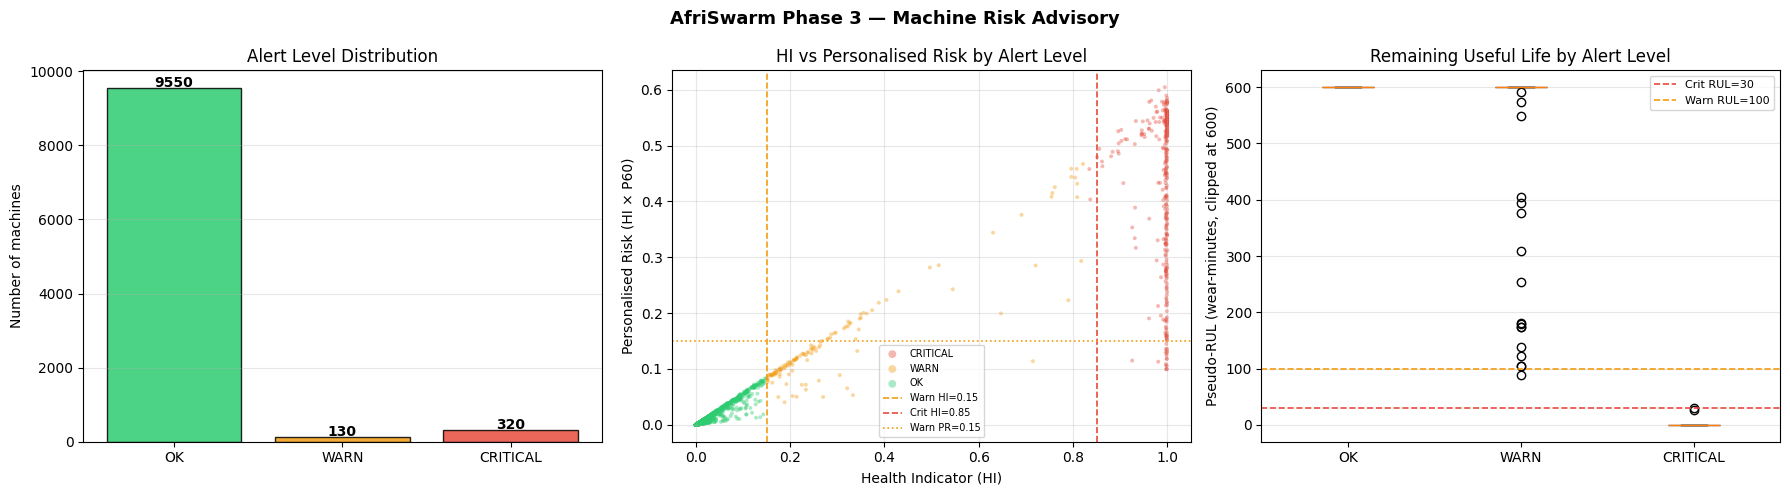

In [ ]:
# ── Build advisory table ─────────────────────────────────────────────────
CRIT_HI          = 0.85   # HI threshold for CRITICAL (= FAILURE_THRESHOLD)
WARN_HI          = 0.15   # HI threshold for WARN
WARN_PR          = 0.15   # personalised-risk threshold for WARN (from asym opt)
CRIT_RUL         = 30     # pseudo-RUL < 30 wear-min → CRITICAL
WARN_RUL         = 100    # pseudo-RUL < 100 wear-min → WARN


def assign_alert(hi, pr, rul):
    if hi >= CRIT_HI or rul < CRIT_RUL:
        return 'CRITICAL'
    if hi >= WARN_HI or pr >= WARN_PR or rul < WARN_RUL:
        return 'WARN'
    return 'OK'


def recommended_action(alert):
    return {
        'CRITICAL': 'Stop machine — schedule immediate inspection',
        'WARN':     'Schedule maintenance within next shift',
        'OK':       'Continue operating — re-check at next wear interval',
    }[alert]


risk_table = hi_df[['udi', 'type', 'tool_wear', 'hi',
                     'p_fail_30', 'p_fail_60',
                     'personalised_risk', 'pseudo_rul']].copy()

risk_table['alert_level'] = [
    assign_alert(row.hi, row.personalised_risk, row.pseudo_rul)
    for row in risk_table.itertuples()
]
risk_table['recommended_action'] = risk_table['alert_level'].map(recommended_action)

# Priority rank within WARN band: highest personalised_risk first
risk_table['warn_priority'] = np.where(
    risk_table['alert_level'] == 'WARN',
    risk_table['personalised_risk'].rank(ascending=False, method='first').astype(int),
    np.nan
)

risk_table.to_csv(f'{BASE}/results/phase3/machine_risk_table.csv', index=False)

# ── Summary ──────────────────────────────────────────────────────────────
alert_counts = risk_table['alert_level'].value_counts()
print('=' * 55)
print('MACHINE RISK ADVISORY SUMMARY')
print('=' * 55)
for level in ['CRITICAL', 'WARN', 'OK']:
    n = alert_counts.get(level, 0)
    pct = 100 * n / len(risk_table)
    print(f'  {level:8s}: {n:5d} machines ({pct:.1f}%)')

print(f'\nTop 10 WARN machines by personalised risk:')
top_warn = (risk_table[risk_table['alert_level'] == 'WARN']
            .sort_values('personalised_risk', ascending=False)
            .head(10))
print(top_warn[['udi', 'type', 'tool_wear', 'hi',
                'personalised_risk', 'pseudo_rul',
                'recommended_action']].to_string(index=False))

print(f'\nAll CRITICAL machines:')
crits = risk_table[risk_table['alert_level'] == 'CRITICAL'].sort_values(
    'hi', ascending=False)
print(crits[['udi', 'type', 'tool_wear', 'hi',
             'personalised_risk', 'pseudo_rul',
             'recommended_action']].to_string(index=False))

print(f'\nAdvisory table saved → {BASE}/results/phase3/machine_risk_table.csv')

# ── Alert level distribution chart ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AfriSwarm Phase 3 — Machine Risk Advisory',
             fontsize=13, fontweight='bold')

# (a) Alert counts
ax = axes[0]
colors_alert = {'CRITICAL': '#e74c3c', 'WARN': '#f39c12', 'OK': '#2ecc71'}
bars = [alert_counts.get(l, 0) for l in ['OK', 'WARN', 'CRITICAL']]
bar_colors = [colors_alert[l] for l in ['OK', 'WARN', 'CRITICAL']]
ax.bar(['OK', 'WARN', 'CRITICAL'], bars, color=bar_colors, edgecolor='black', alpha=0.85)
for i, v in enumerate(bars):
    ax.text(i, v + 20, str(v), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of machines')
ax.set_title('Alert Level Distribution')
ax.grid(True, alpha=0.3, axis='y')

# (b) HI vs personalised risk, coloured by alert level
ax = axes[1]
for level, color in colors_alert.items():
    sub = risk_table[risk_table['alert_level'] == level]
    ax.scatter(sub['hi'], sub['personalised_risk'],
               c=color, alpha=0.4, s=8, label=level, edgecolors='none')
ax.axvline(WARN_HI,  color='#f39c12', linestyle='--', lw=1.2, label=f'Warn HI={WARN_HI}')
ax.axvline(CRIT_HI,  color='#e74c3c', linestyle='--', lw=1.2, label=f'Crit HI={CRIT_HI}')
ax.axhline(WARN_PR,  color='#f39c12', linestyle=':',  lw=1.2, label=f'Warn PR={WARN_PR}')
ax.set_xlabel('Health Indicator (HI)')
ax.set_ylabel('Personalised Risk (HI × P60)')
ax.set_title('HI vs Personalised Risk by Alert Level')
ax.legend(fontsize=7, markerscale=2)
ax.grid(True, alpha=0.3)

# (c) Pseudo-RUL by alert level (box plot)
ax = axes[2]
rul_data  = [risk_table.loc[risk_table['alert_level'] == l,
                             'pseudo_rul'].clip(upper=600).values
             for l in ['OK', 'WARN', 'CRITICAL']]
bp = ax.boxplot(rul_data, labels=['OK', 'WARN', 'CRITICAL'],
                patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], [colors_alert[l]
                                       for l in ['OK', 'WARN', 'CRITICAL']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(CRIT_RUL, color='#e74c3c', linestyle='--', lw=1.2,
           label=f'Crit RUL={CRIT_RUL}')
ax.axhline(WARN_RUL, color='#f39c12', linestyle='--', lw=1.2,
           label=f'Warn RUL={WARN_RUL}')
ax.set_ylabel('Pseudo-RUL (wear-minutes, clipped at 600)')
ax.set_title('Remaining Useful Life by Alert Level')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{BASE}/results/phase3/machine_risk_advisory.png',
            dpi=150, bbox_inches='tight')
plt.show()

## CELL 9 — Weibull-VAE Architecture

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

class WeibullVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=32, hidden=256):
        super().__init__()
        self.latent_dim = latent_dim
        self.enc = nn.Sequential(
            nn.Linear(input_dim, hidden),   nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(hidden, hidden//2),   nn.ReLU(),
        )
        self.fc_mu    = nn.Linear(hidden//2, latent_dim)
        self.fc_logsd = nn.Linear(hidden//2, latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim + 2, hidden//2), nn.ReLU(),
            nn.Linear(hidden//2, hidden),          nn.ReLU(),
            nn.Linear(hidden, input_dim),           nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logsd(h)

    def reparameterise(self, mu, ls):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * ls)

    def decode(self, z, beta, eta):
        return self.dec(torch.cat([z, beta.unsqueeze(1), eta.unsqueeze(1)], dim=1))

    def forward(self, x, beta, eta):
        mu, ls = self.encode(x)
        z = self.reparameterise(mu, ls)
        return self.decode(z, beta, eta), mu, ls


def vae_loss(recon, x, mu, ls, bkl=0.001):
    return F.mse_loss(recon, x, reduction='sum') + \
           bkl * (-0.5 * torch.sum(1 + ls - mu.pow(2) - ls.exp()))


def kl_anneal(epoch, warmup=50):
    """Linear KL annealing from 0 to 1 over warmup epochs"""
    return min(1.0, epoch / warmup)


# Smoke test
ai4i_proc2 = pd.read_csv(f'{BASE}/data/processed/ai4i_processed.csv')
feat_ai4i2 = [c for c in ai4i_proc2.columns if c != target_col]
X_ai4i_np  = ai4i_proc2[feat_ai4i2].select_dtypes(include=np.number).values.astype(np.float32)

vt = WeibullVAE(X_ai4i_np.shape[1]).to(DEVICE)
xt = torch.randn(4, X_ai4i_np.shape[1]).to(DEVICE)
bt = torch.tensor([ai4i_beta] * 4).to(DEVICE)
et = torch.tensor([ai4i_eta]  * 4).to(DEVICE)
out, mu, ls = vt(xt, bt, et)
print(f'WeibullVAE smoke test: input {xt.shape} -> recon {out.shape}')

WeibullVAE smoke test: input torch.Size([4, 10]) -> recon torch.Size([4, 10])


## CELL 10 — Train Weibull-VAE on AI4I

In [ ]:
X_t_ai  = torch.tensor(X_ai4i_np, dtype=torch.float32)
xmin_ai = X_t_ai.min(0).values
xmax_ai = X_t_ai.max(0).values
X_n_ai  = (X_t_ai - xmin_ai) / (xmax_ai - xmin_ai + 1e-9)

sp_ai    = int(0.9 * len(X_n_ai))
tr_dl_ai = DataLoader(TensorDataset(X_n_ai[:sp_ai]), batch_size=128, shuffle=True)
va_dl_ai = DataLoader(TensorDataset(X_n_ai[sp_ai:]), batch_size=256)

vae_ai   = WeibullVAE(X_ai4i_np.shape[1], latent_dim=32, hidden=256).to(DEVICE)
opt_ai   = torch.optim.Adam(vae_ai.parameters(), lr=1e-3)
EPOCHS_AI = 500
sched_ai = torch.optim.lr_scheduler.OneCycleLR(
    opt_ai, max_lr=3e-3,
    steps_per_epoch=len(tr_dl_ai),
    epochs=EPOCHS_AI,
    pct_start=0.3,
    anneal_strategy='cos'
)
CKPT_AI4I = f'{BASE}/models/phase2/vae_ai4i.pt'
best_ai, pc_ai = float('inf'), 0
b_ai = torch.tensor(ai4i_beta, dtype=torch.float32).to(DEVICE)
e_ai = torch.tensor(ai4i_eta,  dtype=torch.float32).to(DEVICE)
KL_WARMUP_AI = 80

print(f'\nTraining AI4I VAE ({len(X_ai4i_np)} samples, hidden=256)...')
for ep in range(1, EPOCHS_AI + 1):
    kl_w = kl_anneal(ep, warmup=KL_WARMUP_AI)
    vae_ai.train()
    for (xb,) in tr_dl_ai:
        xb = xb.to(DEVICE)
        opt_ai.zero_grad()
        r, m, l = vae_ai(xb, b_ai.expand(len(xb)), e_ai.expand(len(xb)))
        loss = vae_loss(r, xb, m, l, bkl=0.001 * kl_w)
        loss.backward()
        opt_ai.step()
        sched_ai.step()
    vae_ai.eval()
    vl = 0
    with torch.no_grad():
        for (xb,) in va_dl_ai:
            xb = xb.to(DEVICE)
            r, m, l = vae_ai(xb, b_ai.expand(len(xb)), e_ai.expand(len(xb)))
            vl += vae_loss(r, xb, m, l, bkl=0.001 * kl_w).item()
    # Only track best after KL warmup completes
    if ep >= KL_WARMUP_AI:
        if vl < best_ai:
            best_ai = vl
            torch.save({'state': vae_ai.state_dict(),
                        'xmin': xmin_ai, 'xmax': xmax_ai,
                        'beta': ai4i_beta, 'eta': ai4i_eta}, CKPT_AI4I)
            pc_ai = 0
        else:
            pc_ai += 1
    if ep % 50 == 0:
        print(f'  ep {ep}: val={vl:.1f}  lr={opt_ai.param_groups[0]["lr"]:.6f}')
print(f'  Best={best_ai:.1f}  Saved: {CKPT_AI4I}')


Training AI4I VAE (10000 samples, hidden=256)...
  ep 50: val=17.2  lr=0.000840
  ep 100: val=15.4  lr=0.002280
  ep 150: val=15.0  lr=0.003000
  ep 200: val=15.6  lr=0.002851
  ep 250: val=14.7  lr=0.002435
  ep 300: val=14.1  lr=0.001834
  ep 350: val=13.6  lr=0.001166
  ep 400: val=13.2  lr=0.000565
  ep 450: val=13.0  lr=0.000148
  ep 500: val=13.0  lr=0.000000
  Best=12.9  Saved: /content/afriswarm/models/phase2/vae_ai4i.pt


## CELL 11 — Generate Synthetic AI4I Data

In [ ]:
c_ai     = torch.load(CKPT_AI4I, map_location=DEVICE, weights_only=False)
vae_ai_g = WeibullVAE(X_ai4i_np.shape[1], latent_dim=32, hidden=256).to(DEVICE)
vae_ai_g.load_state_dict(c_ai['state'])
vae_ai_g.eval()
xmin_ai2 = torch.tensor(c_ai['xmin'], dtype=torch.float32).to(DEVICE)
xmax_ai2 = torch.tensor(c_ai['xmax'], dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    z   = torch.randn(10000, vae_ai_g.latent_dim).to(DEVICE)
    bt  = torch.full((10000,), ai4i_beta, device=DEVICE, dtype=torch.float32)
    et  = torch.full((10000,), ai4i_eta,  device=DEVICE, dtype=torch.float32)
    out = vae_ai_g.decode(z, bt, et)
    out = out * (xmax_ai2 - xmin_ai2 + 1e-9) + xmin_ai2
synth_ai4i = out.cpu().numpy()
pd.DataFrame(synth_ai4i).to_csv(
    f'{BASE}/results/synthetic/synthetic_ai4i.csv', index=False)
print(f'AI4I: 10000 synthetic samples saved')

AI4I: 10000 synthetic samples saved


## CELL 12 — Frechet Distance: Real vs Synthetic

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as _StandardScaler
from scipy.linalg import sqrtm


def frechet_distance(real, synth, n_components=50):
    # Standardize using real-data statistics so FD is scale-invariant
    scaler = _StandardScaler().fit(real)
    real_s = scaler.transform(real)
    synth_s = scaler.transform(synth)
    n = min(n_components, min(real_s.shape[0], real_s.shape[1],
                              synth_s.shape[0], synth_s.shape[1]) - 1)
    pca = PCA(n_components=n).fit(real_s)
    r, s = pca.transform(real_s), pca.transform(synth_s)
    mu_r, cov_r = r.mean(0), np.cov(r, rowvar=False)
    mu_s, cov_s = s.mean(0), np.cov(s, rowvar=False)
    diff = mu_r - mu_s
    cm, _ = sqrtm(cov_r @ cov_s, disp=False)
    if np.iscomplexobj(cm):
        cm = cm.real
    return float(diff @ diff + np.trace(cov_r + cov_s - 2 * cm))


fd_ai4i = frechet_distance(X_ai4i_np, synth_ai4i)

FD_TARGET = 0.15
flag = 'PASS' if fd_ai4i <= FD_TARGET else 'above 0.15 target'
print(f'  AI4I: FD={fd_ai4i:.4f}  [{flag}]')

pd.DataFrame({'Dataset': ['AI4I'],
              'FD': [fd_ai4i],
              'pass': [fd_ai4i <= FD_TARGET]
              }).to_csv(f'{BASE}/results/phase2/ai4i_frechet_distance.csv', index=False)

  AI4I: FD=0.0688  [PASS]


## CELL 13 — TSTR (Train on Synthetic, Test on Real)

In [ ]:
from sklearn.model_selection import train_test_split

X_ai4i_tr, X_ai4i_te, y_ai4i_tr, y_ai4i_te = train_test_split(
    X_ai4i_np, ai4i_proc2[target_col].values,
    test_size=0.2, random_state=SEED, stratify=ai4i_proc2[target_col].values)

# AI4I real-data baseline
xgb_r = XGBClassifier(scale_pos_weight=spw, n_estimators=200, random_state=SEED,
                       eval_metric='logloss', n_jobs=-1)
xgb_r.fit(X_ai4i_tr, y_ai4i_tr)
f1_real_ai4i = f1_score(y_ai4i_te, xgb_r.predict(X_ai4i_te))

# AI4I TSTR: RF labeller + confidence thresholding
from sklearn.ensemble import RandomForestClassifier

CONF_THRESH = 0.80
rf_lab_ai = RandomForestClassifier(200, random_state=SEED, n_jobs=-1)
rf_lab_ai.fit(X_ai4i_tr, y_ai4i_tr)
proba_ai4i = rf_lab_ai.predict_proba(synth_ai4i)
max_ai4i   = proba_ai4i.max(axis=1)
mask_ai    = max_ai4i >= CONF_THRESH
y_sa_conf  = proba_ai4i[mask_ai].argmax(axis=1)
X_sa_conf  = synth_ai4i[mask_ai]
print(f'AI4I: {mask_ai.sum()}/{len(synth_ai4i)} synthetic samples passed confidence filter')

spw2  = max(1, (y_sa_conf == 0).sum() / max(1, (y_sa_conf == 1).sum()))
xgb_s = XGBClassifier(scale_pos_weight=spw2, n_estimators=200, random_state=SEED,
                       eval_metric='logloss', n_jobs=-1)
xgb_s.fit(X_sa_conf, y_sa_conf)
f1_tstr_ai4i = f1_score(y_ai4i_te, xgb_s.predict(X_ai4i_te))

gap = abs(f1_real_ai4i - f1_tstr_ai4i)
print(f'[AI4I] real={f1_real_ai4i:.3f}  tstr={f1_tstr_ai4i:.3f}  gap={gap:.3f}  {"PASS" if gap <= 0.05 else "gap>5%"}')

AI4I: 9889/10000 synthetic samples passed confidence filter
[AI4I] real=0.809  tstr=0.684  gap=0.125  gap>5%


## CELL 14 — Real vs Synthetic Feature Distributions

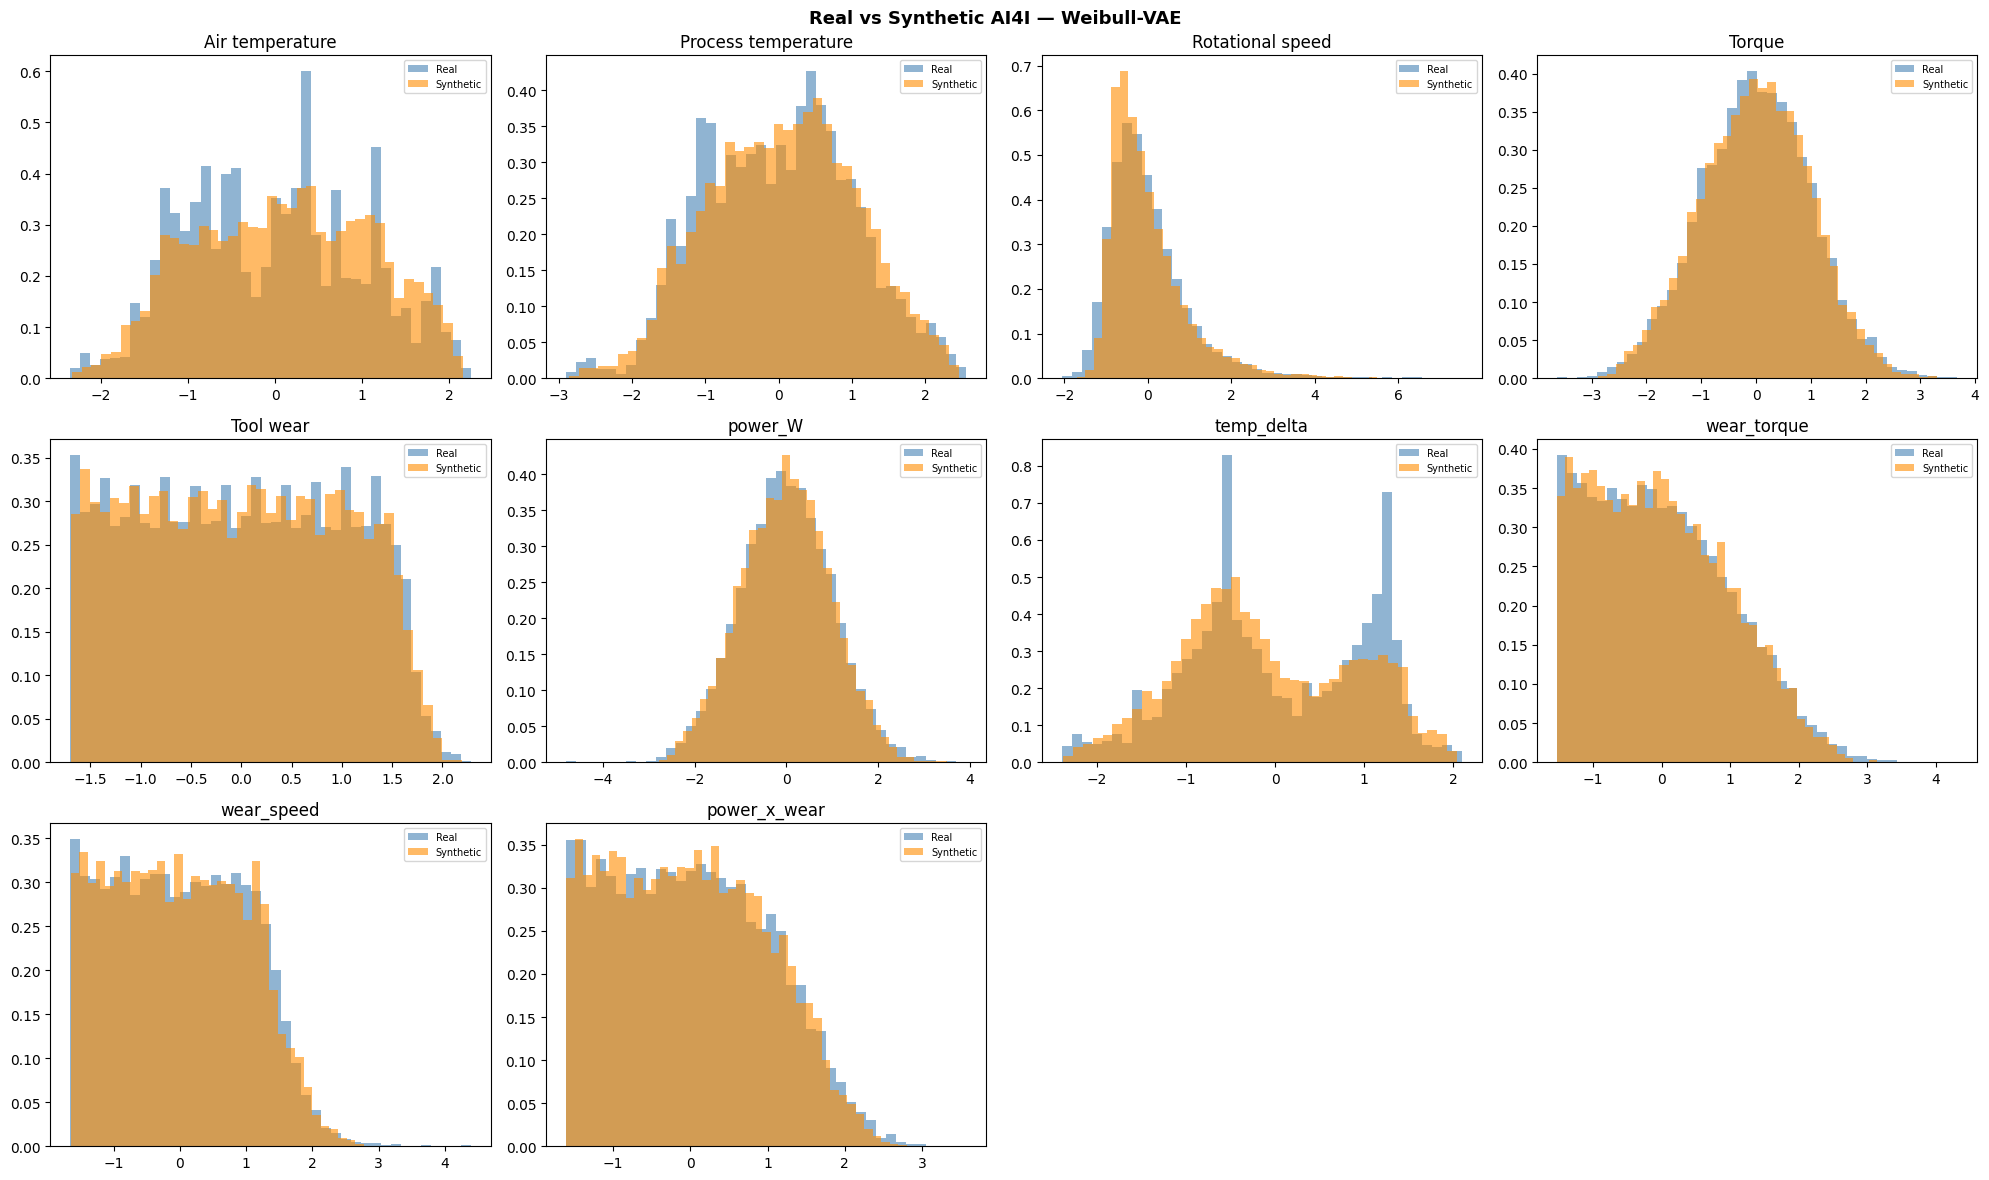

In [ ]:
feat_names = [c for c in ai4i_proc2.columns if c != target_col
              and ai4i_proc2[c].dtype in [np.float64, np.float32, float, int]]

n_feat = len(feat_names)
n_cols = 4
n_rows = (n_feat + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
fig.suptitle('Real vs Synthetic AI4I — Weibull-VAE', fontsize=13, fontweight='bold')
for i in range(n_feat):
    ax = axes[i // n_cols][i % n_cols]
    ax.hist(X_ai4i_np[:, i], bins=40, alpha=0.6, color='steelblue', label='Real', density=True)
    ax.hist(synth_ai4i[:, i], bins=40, alpha=0.6, color='darkorange', label='Synthetic', density=True)
    ax.set_title(feat_names[i] if i < len(feat_names) else f'feat_{i}')
    ax.legend(fontsize=7)
# Hide unused subplots
for i in range(n_feat, n_rows * n_cols):
    axes[i // n_cols][i % n_cols].set_visible(False)
plt.tight_layout()
plt.savefig(f'{BASE}/results/synthetic/real_vs_synthetic_ai4i.png', dpi=150, bbox_inches='tight')
plt.show()

## CELL 15 — Conditional Weibull-VAE (CVAE) Experiment
The unconditional VAE failed to generate fault-class samples because the 29:1
imbalance causes the decoder to learn only the normal-operation manifold.
A CVAE conditions on class label so we can explicitly request fault generation.

In [ ]:
# --- CVAE Architecture ---
class ConditionalWeibullVAE(nn.Module):
    """Weibull-conditioned VAE with explicit class conditioning.
    Encoder receives [features ⊕ one_hot_label], decoder receives [z ⊕ β ⊕ η ⊕ one_hot_label].
    """
    def __init__(self, input_dim, n_classes=2, latent_dim=32, hidden=256):
        super().__init__()
        self.latent_dim = latent_dim
        self.n_classes  = n_classes
        self.enc = nn.Sequential(
            nn.Linear(input_dim + n_classes, hidden), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(hidden, hidden // 2),           nn.ReLU(),
        )
        self.fc_mu    = nn.Linear(hidden // 2, latent_dim)
        self.fc_logsd = nn.Linear(hidden // 2, latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim + 2 + n_classes, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, hidden),                      nn.ReLU(),
            nn.Linear(hidden, input_dim),                         nn.Sigmoid(),
        )

    def encode(self, x, c):
        h = self.enc(torch.cat([x, c], dim=1))
        return self.fc_mu(h), self.fc_logsd(h)

    def decode(self, z, beta, eta, c):
        return self.dec(torch.cat([z, beta.unsqueeze(1), eta.unsqueeze(1), c], dim=1))

    def forward(self, x, beta, eta, c):
        mu, ls = self.encode(x, c)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * ls)
        return self.decode(z, beta, eta, c), mu, ls


# --- Train CVAE on X_ai4i_tr only (no test-set leakage) ---
# Derive normalisation from the training split; the CVAE never touches test rows
X_cvae_t     = torch.tensor(X_ai4i_tr, dtype=torch.float32)
xmin_cvae_tr = X_cvae_t.min(0).values
xmax_cvae_tr = X_cvae_t.max(0).values
X_cvae_n     = (X_cvae_t - xmin_cvae_tr) / (xmax_cvae_tr - xmin_cvae_tr + 1e-9)

y_cvae_tr    = torch.tensor(y_ai4i_tr, dtype=torch.float32)
# One-hot encode: [normal, fault]
C_cvae       = torch.zeros(len(y_cvae_tr), 2)
C_cvae[y_cvae_tr == 0, 0] = 1.0
C_cvae[y_cvae_tr == 1, 1] = 1.0

sp_cvae    = int(0.9 * len(X_cvae_n))
tr_dl_cvae = DataLoader(TensorDataset(X_cvae_n[:sp_cvae], C_cvae[:sp_cvae]),
                         batch_size=128, shuffle=True)
va_dl_cvae = DataLoader(TensorDataset(X_cvae_n[sp_cvae:], C_cvae[sp_cvae:]),
                         batch_size=256)

input_dim_cvae = X_ai4i_np.shape[1]
cvae = ConditionalWeibullVAE(input_dim_cvae, n_classes=2, latent_dim=32, hidden=256).to(DEVICE)
opt_cvae = torch.optim.Adam(cvae.parameters(), lr=1e-3)
EPOCHS_CVAE = 500
sched_cvae = torch.optim.lr_scheduler.OneCycleLR(
    opt_cvae, max_lr=3e-3,
    steps_per_epoch=len(tr_dl_cvae),
    epochs=EPOCHS_CVAE,
    pct_start=0.3,
    anneal_strategy='cos'
)
CKPT_CVAE = f'{BASE}/models/phase2/cvae_ai4i.pt'
best_cvae, pc_cvae = float('inf'), 0
KL_WARMUP_CVAE = 80

# Oversample faults in training to prevent mode collapse to normal class
from torch.utils.data import WeightedRandomSampler

class_counts = np.bincount(y_ai4i_tr[:sp_cvae].astype(int))
weights_per_class = 1.0 / class_counts
sample_weights = weights_per_class[y_ai4i_tr[:sp_cvae].astype(int)]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
tr_dl_cvae = DataLoader(TensorDataset(X_cvae_n[:sp_cvae], C_cvae[:sp_cvae]),
                         batch_size=128, sampler=sampler)

print(f'\nTraining Conditional VAE ({len(X_ai4i_tr)} samples, train-split only, balanced sampling)...')
for ep in range(1, EPOCHS_CVAE + 1):
    kl_w = kl_anneal(ep, warmup=KL_WARMUP_CVAE)
    cvae.train()
    for xb, cb in tr_dl_cvae:
        xb, cb = xb.to(DEVICE), cb.to(DEVICE)
        opt_cvae.zero_grad()
        r, m, l = cvae(xb, b_ai.expand(len(xb)), e_ai.expand(len(xb)), cb)
        loss = vae_loss(r, xb, m, l, bkl=0.001 * kl_w)
        loss.backward()
        opt_cvae.step()
        sched_cvae.step()
    cvae.eval()
    vl = 0
    with torch.no_grad():
        for xb, cb in va_dl_cvae:
            xb, cb = xb.to(DEVICE), cb.to(DEVICE)
            r, m, l = cvae(xb, b_ai.expand(len(xb)), e_ai.expand(len(xb)), cb)
            vl += vae_loss(r, xb, m, l, bkl=0.001 * kl_w).item()
    if ep >= KL_WARMUP_CVAE:
        if vl < best_cvae:
            best_cvae = vl
            torch.save({'state': cvae.state_dict(),
                        'xmin': xmin_cvae_tr, 'xmax': xmax_cvae_tr,
                        'beta': ai4i_beta, 'eta': ai4i_eta}, CKPT_CVAE)
            pc_cvae = 0
        else:
            pc_cvae += 1
    if ep % 50 == 0:
        print(f'  ep {ep}: val={vl:.1f}  lr={opt_cvae.param_groups[0]["lr"]:.6f}')
print(f'  Best={best_cvae:.1f}  Saved: {CKPT_CVAE}')

# --- CVAE Generation Helper ---
c_cvae_ckpt = torch.load(CKPT_CVAE, map_location=DEVICE, weights_only=False)
cvae_gen = ConditionalWeibullVAE(input_dim_cvae, n_classes=2, latent_dim=32, hidden=256).to(DEVICE)
cvae_gen.load_state_dict(c_cvae_ckpt['state'])
cvae_gen.eval()
xmin_cvae = torch.tensor(c_cvae_ckpt['xmin'], dtype=torch.float32).to(DEVICE)
xmax_cvae = torch.tensor(c_cvae_ckpt['xmax'], dtype=torch.float32).to(DEVICE)


def generate_cvae_samples(n_samples, label, seed_offset=0):
    """Generate n_samples from the CVAE conditioned on class label (0=normal, 1=fault)."""
    gen = torch.Generator(device='cpu').manual_seed(SEED + seed_offset)
    z   = torch.randn(n_samples, cvae_gen.latent_dim, generator=gen).to(DEVICE)
    bt  = torch.full((n_samples,), ai4i_beta, device=DEVICE, dtype=torch.float32)
    et  = torch.full((n_samples,), ai4i_eta,  device=DEVICE, dtype=torch.float32)
    c   = torch.zeros(n_samples, 2, device=DEVICE)
    c[:, label] = 1.0
    with torch.no_grad():
        out = cvae_gen.decode(z, bt, et, c)
        out = out * (xmax_cvae - xmin_cvae + 1e-9) + xmin_cvae
    return out.cpu().numpy()


# ── Cold-start experiment setup ────────────────────────────────────────
FAILURE_COUNTS = [0, 1, 2, 5, 10, 20, 50, 100]
N_REPEATS      = 5
all_pos_idx    = np.where(y_ai4i_tr == 1)[0]
all_neg_idx    = np.where(y_ai4i_tr == 0)[0]
X_neg_all      = X_ai4i_tr[all_neg_idx]
y_neg_all      = y_ai4i_tr[all_neg_idx]
print(f'Cold-start setup: {len(all_pos_idx)} fault / {len(all_neg_idx)} normal samples in train split')

# --- Run CVAE Fixed-Failure-Count Experiment ---
records_cvae = []
print('\nCVAE fixed-failure-count experiment\n')

for k in FAILURE_COUNTS:
    for rep in range(N_REPEATS):
        rng = np.random.RandomState(SEED + rep)

        if k == 0:
            Xs, ys = X_neg_all.copy(), y_neg_all.copy()
        else:
            chosen_pos = rng.choice(all_pos_idx, min(k, len(all_pos_idx)), replace=False)
            Xs = np.vstack([X_neg_all, X_ai4i_tr[chosen_pos]])
            ys = np.concatenate([y_neg_all, y_ai4i_tr[chosen_pos]])

        # Generate synthetic FAULT samples directly via class conditioning
        try:
            n_synth_fault = max(100, len(all_neg_idx) // 10)  # ~10% of normal count
            X_sf = generate_cvae_samples(n_synth_fault, label=1, seed_offset=rep)
            y_sf = np.ones(len(X_sf), dtype=int)

            X_aug = np.vstack([Xs, X_sf])
            y_aug = np.concatenate([ys, y_sf])
            spw_cvae = max(1.0, (y_aug == 0).sum() / max(1, (y_aug == 1).sum()))

            xgb_cv = XGBClassifier(scale_pos_weight=spw_cvae, learning_rate=0.05,
                                    max_depth=6, n_estimators=300, subsample=0.8,
                                    colsample_bytree=0.8, random_state=SEED + rep,
                                    eval_metric='logloss', n_jobs=-1)
            xgb_cv.fit(X_aug, y_aug)

            # Default threshold F1
            f1_cvae = f1_score(y_ai4i_te, xgb_cv.predict(X_ai4i_te), zero_division=0)

            # Optimised threshold: search via PR curve on the augmented
            # training set (not test) to avoid leakage
            proba_tr = xgb_cv.predict_proba(X_aug)[:, 1]
            p_tr, r_tr, t_tr = precision_recall_curve(y_aug, proba_tr)
            f1_tr = 2 * p_tr * r_tr / (p_tr + r_tr + 1e-9)
            best_t = float(t_tr[np.argmax(f1_tr)])
            preds_tuned = (xgb_cv.predict_proba(X_ai4i_te)[:, 1] >= best_t).astype(int)
            f1_cvae_tuned = f1_score(y_ai4i_te, preds_tuned, zero_division=0)
        except Exception as e:
            print(f'  CVAE failed k={k} rep={rep}: {e}')
            f1_cvae = 0.0
            f1_cvae_tuned = 0.0
            best_t = 0.5

        records_cvae.append({'k_failures': k, 'repeat': rep,
                             'f1_cvae': f1_cvae, 'f1_cvae_tuned': f1_cvae_tuned,
                             'best_thresh': best_t})
        print(f'k={k:2d} rep={rep}: cvae={f1_cvae:.3f}  tuned={f1_cvae_tuned:.3f}  thresh={best_t:.2f}')

cvae_df = pd.DataFrame(records_cvae)
cvae_df.to_csv(f'{BASE}/results/phase2/ai4i_cvae_experiment.csv', index=False)
print('\nCVAE experiment done')


Training Conditional VAE (8000 samples, train-split only, balanced sampling)...
  ep 50: val=18.9  lr=0.000840
  ep 100: val=13.6  lr=0.002280
  ep 150: val=12.2  lr=0.003000
  ep 200: val=12.2  lr=0.002851
  ep 250: val=13.2  lr=0.002435
  ep 300: val=11.4  lr=0.001834
  ep 350: val=11.3  lr=0.001166
  ep 400: val=10.9  lr=0.000565
  ep 450: val=10.9  lr=0.000148
  ep 500: val=10.8  lr=0.000000
  Best=10.7  Saved: /content/afriswarm/models/phase2/cvae_ai4i.pt
Cold-start setup: 271 fault / 7729 normal samples in train split

CVAE fixed-failure-count experiment

k= 0 rep=0: cvae=0.655  tuned=0.730  thresh=0.68
k= 0 rep=1: cvae=0.633  tuned=0.742  thresh=0.71
k= 0 rep=2: cvae=0.641  tuned=0.757  thresh=0.72
k= 0 rep=3: cvae=0.674  tuned=0.738  thresh=0.68
k= 0 rep=4: cvae=0.663  tuned=0.709  thresh=0.69
k= 1 rep=0: cvae=0.655  tuned=0.726  thresh=0.67
k= 1 rep=1: cvae=0.655  tuned=0.735  thresh=0.71
k= 1 rep=2: cvae=0.641  tuned=0.778  thresh=0.71
k= 1 rep=3: cvae=0.698  tuned=0.718  th

## CELL 15.5 — Ablation: VanillaVAE vs CVAE

In [ ]:
"""## CELL 15.5 — Ablation: VanillaVAE vs CVAE"""

# ── 1. Define and train VanillaVAE ────────────────────────────────────────
class VanillaVAE(nn.Module):
    """Baseline VAE — same depth/width as WeibullVAE, no conditioning of any kind."""
    def __init__(self, input_dim, latent_dim=32, hidden=256):
        super().__init__()
        self.latent_dim = latent_dim
        self.enc = nn.Sequential(
            nn.Linear(input_dim, hidden),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(hidden, hidden//2),  nn.ReLU(),
        )
        self.fc_mu    = nn.Linear(hidden//2, latent_dim)
        self.fc_logsd = nn.Linear(hidden//2, latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, hidden//2), nn.ReLU(),
            nn.Linear(hidden//2, hidden),     nn.ReLU(),
            nn.Linear(hidden, input_dim),      nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logsd(h)

    def forward(self, x):
        mu, ls = self.encode(x)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * ls)
        return self.dec(z), mu, ls


vae_van  = VanillaVAE(X_ai4i_np.shape[1], latent_dim=32, hidden=256).to(DEVICE)
opt_van  = torch.optim.Adam(vae_van.parameters(), lr=1e-3)
sched_van = torch.optim.lr_scheduler.OneCycleLR(
    opt_van, max_lr=3e-3,
    steps_per_epoch=len(tr_dl_ai),
    epochs=EPOCHS_AI, pct_start=0.3, anneal_strategy='cos'
)
CKPT_VAN = f'{BASE}/models/phase2/vae_vanilla_ai4i.pt'
best_van  = float('inf')

print('Training VanillaVAE (no conditioning)...')
for ep in range(1, EPOCHS_AI + 1):
    kl_w = kl_anneal(ep, warmup=80)
    vae_van.train()
    for (xb,) in tr_dl_ai:
        xb = xb.to(DEVICE)
        opt_van.zero_grad()
        r, m, l = vae_van(xb)
        loss = vae_loss(r, xb, m, l, bkl=0.001 * kl_w)
        loss.backward()
        opt_van.step()
        sched_van.step()
    vae_van.eval()
    vl = 0
    with torch.no_grad():
        for (xb,) in va_dl_ai:
            r, m, l = vae_van(xb.to(DEVICE))
            vl += vae_loss(r, xb.to(DEVICE), m, l, bkl=0.001 * kl_w).item()
    if ep >= 80:
        if vl < best_van:
            best_van = vl
            torch.save({'state': vae_van.state_dict(),
                        'xmin': xmin_ai, 'xmax': xmax_ai}, CKPT_VAN)
    if ep % 50 == 0:
        print(f'  ep {ep}: val={vl:.1f}')
print(f'  Best={best_van:.1f}  Saved: {CKPT_VAN}')


# ── 2. Generate synthetic data from VanillaVAE ────────────────────────────
ckpt_van  = torch.load(CKPT_VAN, map_location=DEVICE, weights_only=False)
vae_van_g = VanillaVAE(X_ai4i_np.shape[1], latent_dim=32, hidden=256).to(DEVICE)
vae_van_g.load_state_dict(ckpt_van['state'])
vae_van_g.eval()
xmin_van = torch.tensor(ckpt_van['xmin'], dtype=torch.float32).to(DEVICE)
xmax_van = torch.tensor(ckpt_van['xmax'], dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    z_van     = torch.randn(10000, vae_van_g.latent_dim).to(DEVICE)
    out_van   = vae_van_g.dec(z_van)
    out_van   = out_van * (xmax_van - xmin_van + 1e-9) + xmin_van
synth_van = out_van.cpu().numpy()


# ── 3. Generate synthetic data from CVAE (balanced classes) ───────────────
# Mirror real class ratio: ~96.7% normal, ~3.3% fault, total 10000
n_synth_total  = 10000
n_synth_fault  = int(n_synth_total * (y_ai4i_tr == 1).mean())
n_synth_normal = n_synth_total - n_synth_fault

X_cvae_normal = generate_cvae_samples(n_synth_normal, label=0)
X_cvae_fault  = generate_cvae_samples(n_synth_fault,  label=1)
synth_cvae    = np.vstack([X_cvae_normal, X_cvae_fault])
y_synth_cvae  = np.array([0]*n_synth_normal + [1]*n_synth_fault)
print(f'CVAE: {n_synth_normal} normal + {n_synth_fault} fault samples generated')


# ── 4. Frechet Distance ───────────────────────────────────────────────────
fd_van  = frechet_distance(X_ai4i_np, synth_van)
fd_cvae = frechet_distance(X_ai4i_np, synth_cvae)

print('\n── Frechet Distance (lower = more realistic) ────────────────')
print(f'  VanillaVAE : {fd_van:.4f}')
print(f'  CVAE       : {fd_cvae:.4f}')


# ── 5. TSTR F1 ────────────────────────────────────────────────────────────
# VanillaVAE: use RF confidence filter to assign labels (same as Cell 13)
rf_abl = RandomForestClassifier(200, random_state=SEED, n_jobs=-1)
rf_abl.fit(X_ai4i_tr, y_ai4i_tr)

proba_van_abl = rf_abl.predict_proba(synth_van)
mask_van_abl  = proba_van_abl.max(axis=1) >= CONF_THRESH
X_van_conf    = synth_van[mask_van_abl]
y_van_conf    = proba_van_abl[mask_van_abl].argmax(axis=1)
print(f'\nVanillaVAE: {mask_van_abl.sum()}/{len(synth_van)} samples passed confidence filter')

spw_van_abl = max(1, (y_van_conf==0).sum() / max(1, (y_van_conf==1).sum()))
xgb_van_abl = XGBClassifier(scale_pos_weight=spw_van_abl, n_estimators=200,
                              random_state=SEED, eval_metric='logloss', n_jobs=-1)
xgb_van_abl.fit(X_van_conf, y_van_conf)
f1_tstr_van = f1_score(y_ai4i_te, xgb_van_abl.predict(X_ai4i_te))

# CVAE: labels are known from generation, no confidence filter needed
spw_cvae_abl = max(1, (y_synth_cvae==0).sum() / max(1, (y_synth_cvae==1).sum()))
xgb_cvae_abl = XGBClassifier(scale_pos_weight=spw_cvae_abl, n_estimators=200,
                               random_state=SEED, eval_metric='logloss', n_jobs=-1)
xgb_cvae_abl.fit(synth_cvae, y_synth_cvae)
f1_tstr_cvae = f1_score(y_ai4i_te, xgb_cvae_abl.predict(X_ai4i_te))

print('\n── TSTR F1 (higher = more useful synthetic data) ────────────')
print(f'  VanillaVAE : {f1_tstr_van:.3f}')
print(f'  CVAE       : {f1_tstr_cvae:.3f}')
print(f'  Real data  : {f1_real_ai4i:.3f}')


# ── 6. Summary table ──────────────────────────────────────────────────────
abl_df = pd.DataFrame({
    'Model':   ['VanillaVAE', 'CVAE', 'Real data'],
    'FD':      [round(fd_van, 4), round(fd_cvae, 4), None],
    'TSTR_F1': [round(f1_tstr_van, 3), round(f1_tstr_cvae, 3), round(f1_real_ai4i, 3)],
})
print(f'\n{abl_df.to_string(index=False)}')
abl_df.to_csv(f'{BASE}/results/phase2/ablation_vanilla_vs_cvae.csv', index=False)
print('\nAblation results saved.')

Training VanillaVAE (no conditioning)...
  ep 50: val=11.9
  ep 100: val=15.4
  ep 150: val=14.0
  ep 200: val=13.7
  ep 250: val=13.5
  ep 300: val=13.2
  ep 350: val=12.9
  ep 400: val=13.0
  ep 450: val=12.8
  ep 500: val=12.7
  Best=12.6  Saved: /content/afriswarm/models/phase2/vae_vanilla_ai4i.pt
CVAE: 9662 normal + 338 fault samples generated

── Frechet Distance (lower = more realistic) ────────────────
  VanillaVAE : 0.0314
  CVAE       : 0.0642

VanillaVAE: 9866/10000 samples passed confidence filter

── TSTR F1 (higher = more useful synthetic data) ────────────
  VanillaVAE : 0.806
  CVAE       : 0.301
  Real data  : 0.809

     Model     FD  TSTR_F1
VanillaVAE 0.0314    0.806
      CVAE 0.0642    0.301
 Real data    NaN    0.809

Ablation results saved.


## CELL 15.6 — Cold-Start Recovery: VanillaVAE vs CVAE

Cold-start recovery — VanillaVAE

k=  0 rep=0: van=0.703  tuned=0.557  synthetic_faults_generated=164
k=  0 rep=1: van=0.685  tuned=0.551  synthetic_faults_generated=176
k=  0 rep=2: van=0.690  tuned=0.547  synthetic_faults_generated=171
k=  0 rep=3: van=0.690  tuned=0.526  synthetic_faults_generated=158
k=  0 rep=4: van=0.726  tuned=0.562  synthetic_faults_generated=178
k=  1 rep=0: van=0.673  tuned=0.620  synthetic_faults_generated=175
k=  1 rep=1: van=0.746  tuned=0.553  synthetic_faults_generated=171
k=  1 rep=2: van=0.697  tuned=0.627  synthetic_faults_generated=186
k=  1 rep=3: van=0.743  tuned=0.580  synthetic_faults_generated=181
k=  1 rep=4: van=0.702  tuned=0.566  synthetic_faults_generated=163
k=  2 rep=0: van=0.737  tuned=0.620  synthetic_faults_generated=187
k=  2 rep=1: van=0.714  tuned=0.641  synthetic_faults_generated=170
k=  2 rep=2: van=0.726  tuned=0.608  synthetic_faults_generated=162
k=  2 rep=3: van=0.691  tuned=0.542  synthetic_faults_generated=154
k=  2 rep=4: v

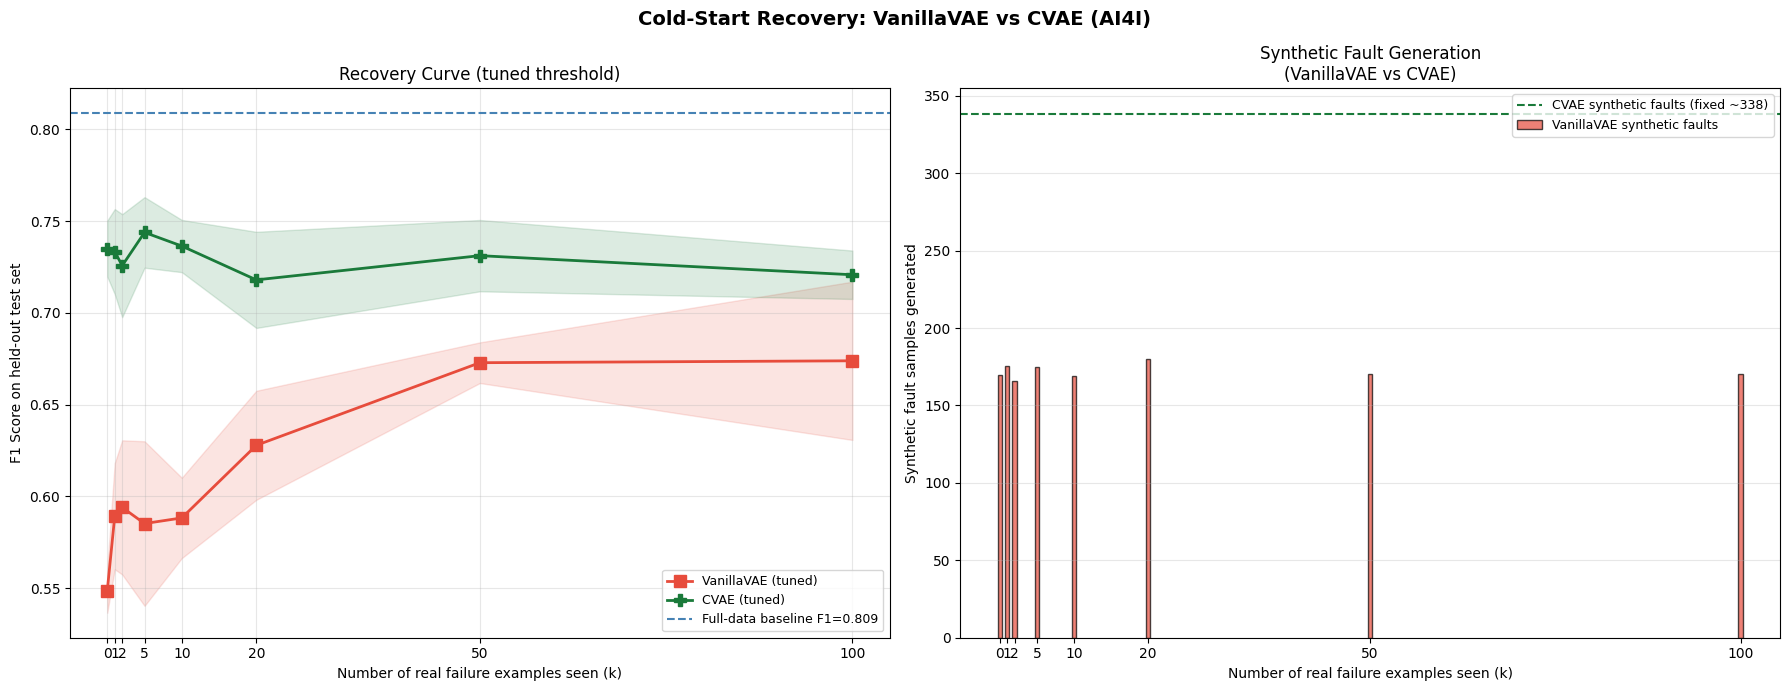

Cold-start comparison saved.


In [ ]:
"""## CELL 15.6 — Cold-Start Recovery: VanillaVAE vs CVAE"""

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_recall_curve

# ── 1. Run cold-start experiment for VanillaVAE ───────────────────────────
# Mirror Cell 15's setup exactly — only the synthetic data source changes
records_van = []
print('Cold-start recovery — VanillaVAE\n')

for k in FAILURE_COUNTS:
    for rep in range(N_REPEATS):
        rng = np.random.RandomState(SEED + rep)

        if k == 0:
            Xs, ys = X_neg_all.copy(), y_neg_all.copy()
        else:
            chosen_pos = rng.choice(all_pos_idx, min(k, len(all_pos_idx)), replace=False)
            Xs = np.vstack([X_neg_all, X_ai4i_tr[chosen_pos]])
            ys = np.concatenate([y_neg_all, y_ai4i_tr[chosen_pos]])

        # Generate from VanillaVAE and use RF confidence filter to assign labels
        # (we expect it to assign almost everything as normal)
        try:
            with torch.no_grad():
                z_v = torch.randn(10000, vae_van_g.latent_dim).to(DEVICE)
                out_v = vae_van_g.dec(z_v)
                out_v = out_v * (xmax_van - xmin_van + 1e-9) + xmin_van
            X_van_rep = out_v.cpu().numpy()

            rf_lab_v = RandomForestClassifier(200, random_state=SEED + rep, n_jobs=-1)
            rf_lab_v.fit(X_ai4i_tr, y_ai4i_tr)
            proba_v = rf_lab_v.predict_proba(X_van_rep)
            mask_v  = proba_v.max(axis=1) >= CONF_THRESH
            X_v_conf = X_van_rep[mask_v]
            y_v_conf = proba_v[mask_v].argmax(axis=1)

            n_fault_synth = (y_v_conf == 1).sum()

            X_aug_v = np.vstack([Xs, X_v_conf])
            y_aug_v = np.concatenate([ys, y_v_conf])

            spw_v = max(1.0, (y_aug_v == 0).sum() / max(1, (y_aug_v == 1).sum()))
            xgb_v = XGBClassifier(scale_pos_weight=spw_v, learning_rate=0.05,
                                   max_depth=6, n_estimators=300, subsample=0.8,
                                   colsample_bytree=0.8, random_state=SEED + rep,
                                   eval_metric='logloss', n_jobs=-1)
            xgb_v.fit(X_aug_v, y_aug_v)

            f1_van = f1_score(y_ai4i_te, xgb_v.predict(X_ai4i_te), zero_division=0)

            # Tuned threshold
            proba_tr_v = xgb_v.predict_proba(X_aug_v)[:, 1]
            p_v, r_v, t_v = precision_recall_curve(y_aug_v, proba_tr_v)
            f1_tr_v = 2 * p_v * r_v / (p_v + r_v + 1e-9)
            best_t_v = float(t_v[np.argmax(f1_tr_v)])
            preds_tuned_v = (xgb_v.predict_proba(X_ai4i_te)[:, 1] >= best_t_v).astype(int)
            f1_van_tuned = f1_score(y_ai4i_te, preds_tuned_v, zero_division=0)

        except Exception as e:
            print(f'  VanillaVAE failed k={k} rep={rep}: {e}')
            f1_van = 0.0
            f1_van_tuned = 0.0
            n_fault_synth = 0

        records_van.append({'k_failures': k, 'repeat': rep,
                            'f1_van': f1_van, 'f1_van_tuned': f1_van_tuned,
                            'n_fault_synth': n_fault_synth})
        print(f'k={k:3d} rep={rep}: van={f1_van:.3f}  tuned={f1_van_tuned:.3f}'
              f'  synthetic_faults_generated={n_fault_synth}')

van_df = pd.DataFrame(records_van)
van_df.to_csv(f'{BASE}/results/phase2/vanilla_coldstart.csv', index=False)
print('\nVanillaVAE cold-start done')


# ── 2. Plot VanillaVAE vs CVAE recovery curves ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Cold-Start Recovery: VanillaVAE vs CVAE (AI4I)',
             fontsize=14, fontweight='bold')

# Left panel — tuned F1 curves for both models
ax = axes[0]
for df, col, label, color, marker in [
    (van_df,  'f1_van_tuned',   'VanillaVAE (tuned)', '#e74c3c', 's'),
    (cvae_df, 'f1_cvae_tuned',  'CVAE (tuned)',        '#1a7a3a', 'P'),
]:
    m = df.groupby('k_failures')[col].mean()
    e = 1.96 * df.groupby('k_failures')[col].std() / np.sqrt(N_REPEATS)
    ax.plot(m.index, m.values, marker=marker, label=label,
            color=color, lw=2, ms=8)
    ax.fill_between(m.index, m - e, m + e, alpha=0.15, color=color)

ax.axhline(f1_real_ai4i, linestyle='--', color='steelblue', lw=1.5,
           label=f'Full-data baseline F1={f1_real_ai4i:.3f}')
ax.set_xlabel('Number of real failure examples seen (k)')
ax.set_ylabel('F1 Score on held-out test set')
ax.set_title('Recovery Curve (tuned threshold)')
ax.set_xticks(FAILURE_COUNTS)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right panel — synthetic faults generated per k (VanillaVAE only)
# Shows directly why VanillaVAE fails at low k
ax2 = axes[1]
van_faults = van_df.groupby('k_failures')['n_fault_synth'].mean()
ax2.bar(van_faults.index, van_faults.values,
        color='#e74c3c', alpha=0.7, width=0.6, edgecolor='black',
        label='VanillaVAE synthetic faults')
ax2.axhline(338, linestyle='--', color='#1a7a3a', lw=1.5,
            label='CVAE synthetic faults (fixed ~338)')
ax2.set_xlabel('Number of real failure examples seen (k)')
ax2.set_ylabel('Synthetic fault samples generated')
ax2.set_title('Synthetic Fault Generation\n(VanillaVAE vs CVAE)')
ax2.set_xticks(FAILURE_COUNTS)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{BASE}/results/phase2/coldstart_vanilla_vs_cvae.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Cold-start comparison saved.')

## CELL 16 — CVAE Cold-Start Recovery Chart

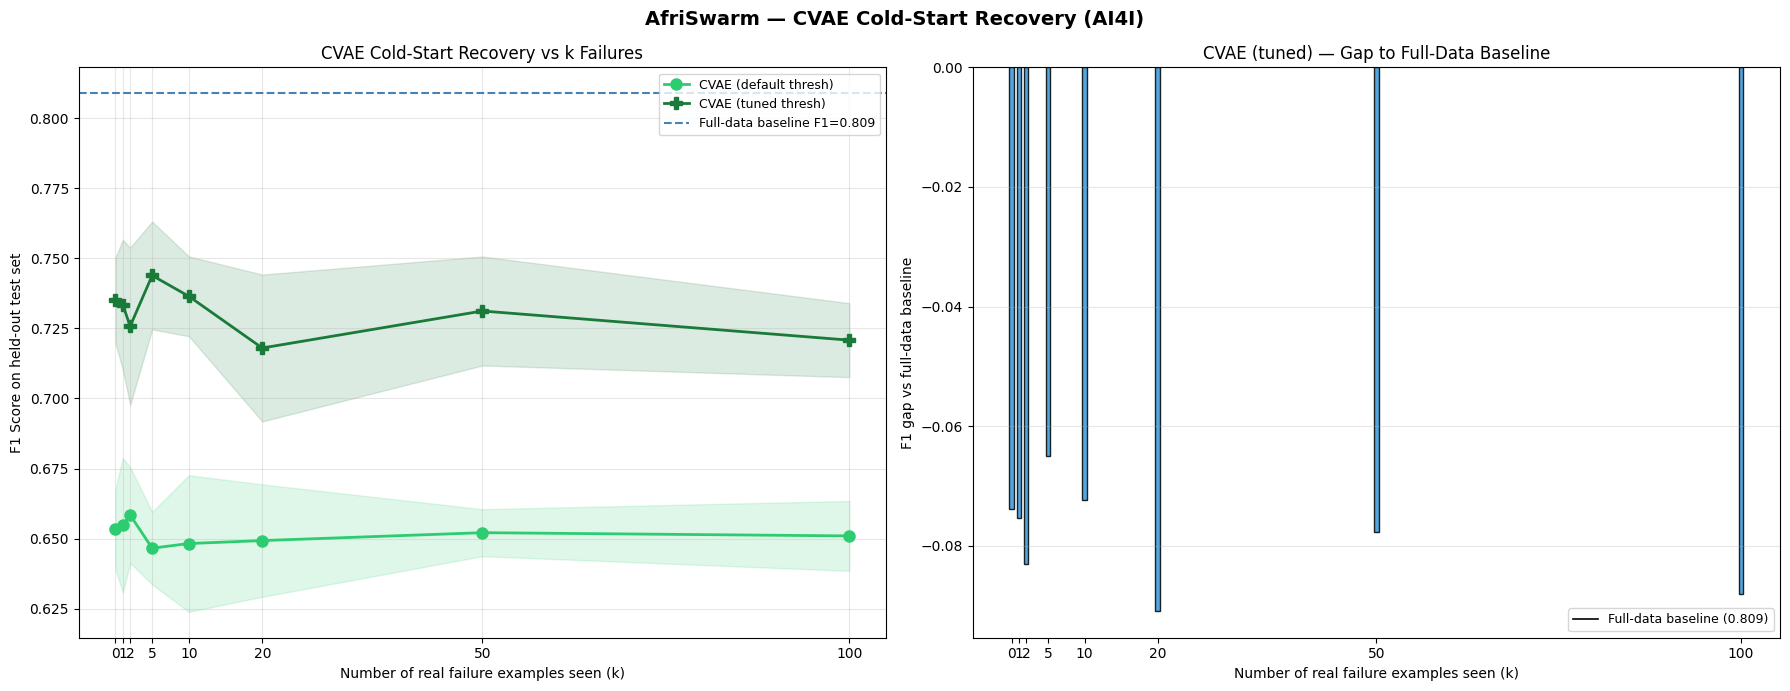


CVAE Cold-Start Recovery — Mean F1 by k:
    k    Default      Tuned   Gap-to-Full
    0      0.653      0.735        -0.074
    1      0.655      0.733        -0.075
    2      0.658      0.726        -0.083
    5      0.647      0.744        -0.065
   10      0.648      0.736        -0.072
   20      0.649      0.718        -0.091
   50      0.652      0.731        -0.078
  100      0.651      0.721        -0.088


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('AfriSwarm — CVAE Cold-Start Recovery (AI4I)', fontsize=14, fontweight='bold')

# --- Left panel: CVAE default vs tuned threshold across k ---
ax = axes[0]
for col, label, color, marker in [
    ('f1_cvae',       'CVAE (default thresh)', '#2ecc71', 'o'),
    ('f1_cvae_tuned', 'CVAE (tuned thresh)',   '#1a7a3a', 'P'),
]:
    m = cvae_df.groupby('k_failures')[col].mean()
    e = 1.96 * cvae_df.groupby('k_failures')[col].std() / np.sqrt(N_REPEATS)
    ax.plot(m.index, m.values, marker=marker, label=label, color=color, lw=2, ms=8)
    ax.fill_between(m.index, m - e, m + e, alpha=0.15, color=color)
ax.axhline(f1_real_ai4i, linestyle='--', color='steelblue', lw=1.5,
           label=f'Full-data baseline F1={f1_real_ai4i:.3f}')
ax.set_xlabel('Number of real failure examples seen (k)')
ax.set_ylabel('F1 Score on held-out test set')
ax.set_title('CVAE Cold-Start Recovery vs k Failures')
ax.set_xticks(FAILURE_COUNTS)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Right panel: tuned threshold recovery vs full-data gap ---
ax2 = axes[1]
cvae_tuned_mean = cvae_df.groupby('k_failures')['f1_cvae_tuned'].mean()
gap_to_full = cvae_tuned_mean - f1_real_ai4i   # negative = still below full-data

bar_colors = ['#1a7a3a' if g >= 0 else '#3498db' for g in gap_to_full.values]
ax2.bar(gap_to_full.index, gap_to_full.values,
        color=bar_colors, width=0.6, edgecolor='black', alpha=0.85)
ax2.axhline(0, color='black', lw=1.2, label=f'Full-data baseline ({f1_real_ai4i:.3f})')
ax2.set_xlabel('Number of real failure examples seen (k)')
ax2.set_ylabel('F1 gap vs full-data baseline')
ax2.set_title('CVAE (tuned) — Gap to Full-Data Baseline')
ax2.set_xticks(FAILURE_COUNTS)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{BASE}/results/phase2/ai4i_cvae_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print('\nCVAE Cold-Start Recovery — Mean F1 by k:')
print(f'  {"k":>3s}  {"Default":>9s}  {"Tuned":>9s}  {"Gap-to-Full":>12s}')
for k in FAILURE_COUNTS:
    row   = cvae_df[cvae_df['k_failures'] == k]
    cv_m  = row['f1_cvae'].mean()
    cvt_m = row['f1_cvae_tuned'].mean()
    gap   = cvt_m - f1_real_ai4i
    print(f'  {k:3d}  {cv_m:9.3f}  {cvt_m:9.3f}  {gap:+12.3f}')

# Phase 4: Wiener Process RUL Estimator

## CELL 19 — Derive Wiener Process Parameters from Weibull Fit

In [ ]:
from scipy.special import gamma as _gamma
from scipy.stats   import norm as _norm
from dataclasses   import dataclass, field
from typing        import Dict, List, Optional, Tuple
import matplotlib.patches as mpatches

os.makedirs(f'{BASE}/results/phase4', exist_ok=True)

# Retrieve the Weibull parameters saved in Phase 2.
beta_w = weibull_params['AI4I']['beta']   # shape parameter  — 1.974
eta_w  = weibull_params['AI4I']['eta']    # scale parameter  — 187.70

# HI failure threshold from Phase 3
HI_THRESHOLD = 0.85

# ── Composite degradation index ─────────────────────────────────────────────
# The raw HI is near-zero for 97% of machines (R² ≈ 0.02 vs tool_wear) and
# only spikes at failure.  Using it directly gives identical RUL for all low-HI
# machines.  Fix: blend normalized wear (monotonic) with normalized HI.


def degradation_index(tool_wear, hi, eta_w, hi_threshold=HI_THRESHOLD):
    """Composite degradation signal: normalized wear + normalized HI."""
    return np.asarray(tool_wear, dtype=float) / eta_w + np.asarray(hi, dtype=float) / hi_threshold


D_THRESHOLD = 2.0   # Composite: d=1 (full wear) + d=1 (full HI)

# Step A: Compute Weibull first two moments
E_T_weibull   = eta_w * _gamma(1.0 + 1.0 / beta_w)
Var_T_weibull = eta_w**2 * (_gamma(1.0 + 2.0 / beta_w) - _gamma(1.0 + 1.0 / beta_w)**2)

print(f'Weibull moments derived from Phase 2 parameters:')
print(f'  E[T]   = {E_T_weibull:.2f} wear-minutes  (population mean time to failure)')
print(f'  Var[T] = {Var_T_weibull:.2f} wear-minutes²')

# Step B: Derive Wiener drift μ (with D=2.0 composite threshold)
MU_PRIOR = D_THRESHOLD / E_T_weibull

# Step C: Derive Wiener diffusion σ²
SIGMA_SQ = Var_T_weibull * MU_PRIOR**3 / D_THRESHOLD
SIGMA    = np.sqrt(SIGMA_SQ)

# Step D: Set prior uncertainty on μ (τ₀²)
TAU_PRIOR_SQ = (0.5 * MU_PRIOR) ** 2

print(f'\nDerived Wiener process parameters (composite degradation index):')
print(f'  μ (drift)  = {MU_PRIOR:.8f} d-units per wear-minute')
print(f'  σ (diffusion) = {SIGMA:.8f}')
print(f'  σ²         = {SIGMA_SQ:.10f}')
print(f'  τ₀ (prior std on μ) = {np.sqrt(TAU_PRIOR_SQ):.8f}')
print(f'  D (composite failure threshold) = {D_THRESHOLD}')
print(f'  HI failure threshold = {HI_THRESHOLD}')

Weibull moments derived from Phase 2 parameters:
  E[T]   = 166.39 wear-minutes  (population mean time to failure)
  Var[T] = 7742.11 wear-minutes²

Derived Wiener process parameters (composite degradation index):
  μ (drift)  = 0.01201993 d-units per wear-minute
  σ (diffusion) = 0.08199129
  σ²         = 0.0067225709
  τ₀ (prior std on μ) = 0.00600997
  D (composite failure threshold) = 2.0
  HI failure threshold = 0.85


## CELL 20 — Core Wiener Process Functions

In [ ]:
def fpt_cdf(t: np.ndarray,
            x_current: float,
            mu: float,
            sigma: float,
            D: float = D_THRESHOLD) -> np.ndarray:
    """
    First-passage-time CDF: P(failure occurs within t more wear-minutes |
    current health indicator = x_current).
    """
    gap = D - x_current
    if gap <= 0:
        return np.ones_like(t, dtype=float)
    if mu <= 0:
        return np.zeros_like(t, dtype=float)

    t = np.maximum(t, 1e-9)
    sqrt_t = np.sqrt(t)

    term1 = _norm.cdf((mu * t - gap) / (sigma * sqrt_t))
    exp_factor = np.exp(np.clip(2.0 * mu * gap / (sigma**2), -500, 500))
    term2 = exp_factor * _norm.cdf(-(mu * t + gap) / (sigma * sqrt_t))

    return np.clip(term1 + term2, 0.0, 1.0)


def rul_quantiles(x_current: float,
                  mu: float,
                  sigma: float,
                  D: float = D_THRESHOLD,
                  quantiles: Tuple[float, ...] = (0.10, 0.50, 0.90),
                  t_max: float = 500.0,
                  n_points: int = 1000) -> Dict[float, float]:
    """
    Compute RUL quantiles by numerically inverting the FPT CDF.
    Returns {quantile: wear_minutes_to_failure}.
    """
    if x_current >= D:
        return {q: 0.0 for q in quantiles}

    t_grid = np.linspace(0.1, t_max, n_points)
    cdf    = fpt_cdf(t_grid, x_current, mu, sigma, D)

    result = {}
    for q in quantiles:
        idx = np.searchsorted(cdf, q)
        if idx >= len(t_grid):
            result[q] = float(t_max)
        elif idx == 0:
            result[q] = float(t_grid[0])
        else:
            t_lo, t_hi = t_grid[idx - 1], t_grid[idx]
            c_lo, c_hi = cdf[idx - 1], cdf[idx]
            if c_hi > c_lo:
                frac = (q - c_lo) / (c_hi - c_lo)
                result[q] = float(t_lo + frac * (t_hi - t_lo))
            else:
                result[q] = float(t_lo)
    return result


def bayesian_update_mu(mu_prior: float,
                       tau_sq_prior: float,
                       delta_hi_observations: np.ndarray,
                       delta_wear_observations: np.ndarray,
                       sigma_sq: float) -> Tuple[float, float]:
    """
    Bayesian update of the machine-specific drift parameter μ.
    Conjugate Normal-Normal update.
    """
    prior_precision = 1.0 / tau_sq_prior
    data_precision = np.sum(delta_wear_observations) / sigma_sq
    data_sufficient_stat = np.sum(delta_hi_observations) / sigma_sq

    posterior_precision = prior_precision + data_precision
    mu_posterior        = (mu_prior * prior_precision + data_sufficient_stat) / posterior_precision
    tau_sq_posterior    = 1.0 / posterior_precision

    mu_posterior = max(mu_posterior, 1e-10)
    return mu_posterior, tau_sq_posterior

## CELL 21 — MachineState: Per-Machine Sequential Tracker

In [ ]:
@dataclass
class MachineState:
    """Maintains the running Bayesian state for a single machine."""
    machine_id          : int
    machine_type        : str
    mu                  : float   = field(default_factory=lambda: MU_PRIOR)
    tau_sq              : float   = field(default_factory=lambda: TAU_PRIOR_SQ)
    hi_history          : List[float] = field(default_factory=list)
    wear_history        : List[float] = field(default_factory=list)
    n_updates           : int     = 0
    wear_rate_per_cycle : Optional[float] = None

    def update(self, new_hi: float, new_wear: float) -> None:
        """Ingest a new (HI, wear) reading and update the Bayesian drift posterior."""
        self.hi_history.append(new_hi)
        self.wear_history.append(new_wear)

        if len(self.hi_history) < 2:
            return

        delta_hi   = np.array([self.hi_history[-1]   - self.hi_history[-2]])
        delta_wear = np.array([self.wear_history[-1]  - self.wear_history[-2]])

        if delta_wear[0] <= 0 or delta_hi[0] < 0:
            return

        self.mu, self.tau_sq = bayesian_update_mu(
            self.mu, self.tau_sq,
            delta_hi, delta_wear,
            SIGMA_SQ
        )
        self.n_updates += 1

    def predict(self,
                quantiles: Tuple[float, ...] = (0.10, 0.50, 0.90)
                ) -> Dict[str, object]:
        """Compute the current RUL distribution and supporting diagnostics."""
        current_hi = self.hi_history[-1] if self.hi_history else 0.0
        q_dict     = rul_quantiles(current_hi, self.mu, SIGMA, D_THRESHOLD, quantiles)

        if self.n_updates < 5:
            regime = 'prior-dominated'
        elif self.n_updates < 20:
            regime = 'data-informed'
        else:
            regime = 'machine-specific'

        rul_cycles = None
        if self.wear_rate_per_cycle and self.wear_rate_per_cycle > 0:
            rul_cycles = q_dict.get(0.50, 0.0) / self.wear_rate_per_cycle

        return {
            'machine_id'       : self.machine_id,
            'machine_type'     : self.machine_type,
            'current_hi'       : current_hi,
            'mu_posterior'     : self.mu,
            'tau_posterior'    : np.sqrt(self.tau_sq),
            'n_updates'        : self.n_updates,
            'regime'           : regime,
            **{f'rul_p{int(q*100)}': q_dict[q] for q in quantiles},
            'rul_cycles_p50'   : rul_cycles,
        }

## CELL 22 — Batch RUL Computation Across All AI4I Machines

In [ ]:
print('=' * 60)
print('PHASE 4 — WIENER PROCESS RUL ESTIMATION')
print('=' * 60)

hi_phase3 = pd.read_csv(f'{BASE}/results/phase3/ai4i_health_indicator.csv')

print(f'\nLoaded {len(hi_phase3)} machine records from Phase 3 output.')
print(f'Health indicator range: [{hi_phase3["hi"].min():.4f}, {hi_phase3["hi"].max():.4f}]')

machine_states: Dict[int, MachineState] = {}

for row in hi_phase3.itertuples(index=False):
    state = MachineState(
        machine_id   = int(row.udi),
        machine_type = str(row.type),
        mu     = MU_PRIOR,
        tau_sq = TAU_PRIOR_SQ,
    )
    d_idx = float(degradation_index(row.tool_wear, row.hi, eta_w))
    state.update(new_hi=d_idx, new_wear=float(row.tool_wear))
    machine_states[int(row.udi)] = state

print(f'Initialised {len(machine_states)} MachineState objects.')

records_phase4 = []
for uid, state in machine_states.items():
    pred = state.predict(quantiles=(0.10, 0.50, 0.90))
    records_phase4.append(pred)

phase4_df = pd.DataFrame(records_phase4)

phase3_risk = pd.read_csv(f'{BASE}/results/phase3/machine_risk_table.csv')
phase4_merged = phase3_risk.merge(
    phase4_df[['machine_id', 'rul_p10', 'rul_p50', 'rul_p90',
               'mu_posterior', 'tau_posterior', 'n_updates', 'regime']],
    left_on='udi', right_on='machine_id', how='left'
)
phase4_merged.drop(columns='machine_id', inplace=True)
phase4_merged.to_csv(f'{BASE}/results/phase4/machine_rul_full.csv', index=False)

print('\nRUL distribution summary (wear-minutes, all machines):')
print(f'  P10 (pessimistic): mean={phase4_df["rul_p10"].mean():.1f}  '
      f'median={phase4_df["rul_p10"].median():.1f}')
print(f'  P50 (median):      mean={phase4_df["rul_p50"].mean():.1f}  '
      f'median={phase4_df["rul_p50"].median():.1f}')
print(f'  P90 (optimistic):  mean={phase4_df["rul_p90"].mean():.1f}  '
      f'median={phase4_df["rul_p90"].median():.1f}')

print('\nRUL distribution by alert level:')
for level in ['CRITICAL', 'WARN', 'OK']:
    sub = phase4_merged[phase4_merged['alert_level'] == level]
    if len(sub) > 0:
        print(f'  {level:8s} (n={len(sub):5d}):  '
              f'P50 mean={sub["rul_p50"].mean():.1f}  '
              f'P10 mean={sub["rul_p10"].mean():.1f}  '
              f'P90 mean={sub["rul_p90"].mean():.1f}')

print(f'\nAll machines in prior-dominated regime (1 reading each): '
      f'{(phase4_df["regime"] == "prior-dominated").sum()}')
print('This is expected — AI4I is a snapshot dataset.  In deployment, ')
print('regime labels will shift to data-informed / machine-specific as ')
print('sequential readings accumulate.')

PHASE 4 — WIENER PROCESS RUL ESTIMATION

Loaded 10000 machine records from Phase 3 output.
Health indicator range: [0.0000, 1.0000]
Initialised 10000 MachineState objects.

RUL distribution summary (wear-minutes, all machines):
  P10 (pessimistic): mean=46.7  median=46.8
  P50 (median):      mean=96.5  median=98.1
  P90 (optimistic):  mean=206.2  median=211.4

RUL distribution by alert level:
  CRITICAL (n=  320):  P50 mean=11.1  P10 mean=3.9  P90 mean=36.5
  WARN     (n=  130):  P50 mean=39.4  P10 mean=15.6  P90 mean=109.6
  OK       (n= 9550):  P50 mean=100.1  P10 mean=48.6  P90 mean=213.2

All machines in prior-dominated regime (1 reading each): 10000
This is expected — AI4I is a snapshot dataset.  In deployment, 
regime labels will shift to data-informed / machine-specific as 
sequential readings accumulate.


## CELL 23 — Bayesian Update Demonstration (Simulated Sequential Readings)

In [ ]:
print('\n' + '=' * 60)
print('BAYESIAN UPDATE DEMONSTRATION — Simulated Sequential Machine')
print('=' * 60)

# Pick a machine at moderate wear so the simulation has room to run many steps.
moderate_mask = (
    (phase4_merged['alert_level'] == 'OK') &
    (phase4_merged['tool_wear'] >= 60) &
    (phase4_merged['tool_wear'] <= 120)
)
moderate_machines = phase4_merged[moderate_mask].sort_values('tool_wear')
if len(moderate_machines) > 0:
    seed_row = moderate_machines.iloc[len(moderate_machines) // 2]
else:
    seed_row = phase4_merged.sort_values('tool_wear').iloc[len(phase4_merged) // 3]

np.random.seed(42)

demo_state = MachineState(
    machine_id   = int(seed_row['udi']),
    machine_type = str(seed_row['type']),
    mu     = MU_PRIOR * 0.8,
    tau_sq = TAU_PRIOR_SQ,
)

MU_TRUE   = MU_PRIOR * 1.3
WEAR_STEP = 5

current_wear = float(seed_row['tool_wear'])
current_hi   = float(seed_row['hi'])
current_d    = float(degradation_index(current_wear, current_hi, eta_w))
demo_state.update(current_d, current_wear)

demo_snapshots = []
N_SIM_STEPS = 60

for step in range(N_SIM_STEPS):
    delta_d_true = MU_TRUE * WEAR_STEP + SIGMA * np.sqrt(WEAR_STEP) * np.random.randn()
    delta_d_true = max(0.0, delta_d_true)
    current_d    = min(current_d + delta_d_true, D_THRESHOLD)
    current_wear = current_wear + WEAR_STEP

    demo_state.update(current_d, current_wear)
    pred = demo_state.predict()

    demo_snapshots.append({
        'step'          : step + 1,
        'wear'          : current_wear,
        'hi'            : current_d,
        'mu_posterior'  : pred['mu_posterior'],
        'tau_posterior' : pred['tau_posterior'],
        'rul_p10'       : pred['rul_p10'],
        'rul_p50'       : pred['rul_p50'],
        'rul_p90'       : pred['rul_p90'],
        'regime'        : pred['regime'],
        'n_updates'     : pred['n_updates'],
    })

    if current_d >= D_THRESHOLD:
        print(f'  Simulated machine reached failure threshold at step {step+1}, '
              f'wear={current_wear:.0f}')
        break

demo_snap_df = pd.DataFrame(demo_snapshots)
demo_snap_df.to_csv(f'{BASE}/results/phase4/bayesian_update_demo.csv', index=False)

print(f'\nSimulated {len(demo_snap_df)} sequential readings for machine UDI={seed_row["udi"]}')
print(f'  True drift μ_true = {MU_TRUE:.8f}   '
      f'(1.3× population prior = {MU_PRIOR:.8f})')
print(f'  Initial μ estimate: {MU_PRIOR * 0.8:.8f}  (deliberately biased low)')
print(f'  Final μ posterior:  {demo_state.mu:.8f}  '
      f'(converging toward true value)')
print(f'  Final regime:       {demo_snap_df["regime"].iloc[-1]}')
print(f'\n  Step-by-step RUL evolution (selected steps):')
print(f'  {"Step":>5}  {"Wear":>6}  {"d_idx":>7}  '
      f'{"μ_post":>10}  {"P10":>6}  {"P50":>6}  {"P90":>6}  Regime')
for _, r in demo_snap_df.iloc[::5].iterrows():
    print(f'  {r["step"]:5.0f}  {r["wear"]:6.0f}  {r["hi"]:7.4f}  '
          f'{r["mu_posterior"]:10.8f}  {r["rul_p10"]:6.1f}  '
          f'{r["rul_p50"]:6.1f}  {r["rul_p90"]:6.1f}  {r["regime"]}')


BAYESIAN UPDATE DEMONSTRATION — Simulated Sequential Machine
  Simulated machine reached failure threshold at step 10, wear=140

Simulated 10 sequential readings for machine UDI=3310
  True drift μ_true = 0.01562591   (1.3× population prior = 0.01201993)
  Initial μ estimate: 0.00961595  (deliberately biased low)
  Final μ posterior:  0.01398391  (converging toward true value)
  Final regime:       data-informed

  Step-by-step RUL evolution (selected steps):
   Step    Wear    d_idx      μ_post     P10     P50     P90  Regime
      1      95   0.6570  0.01024967    47.3   105.9   246.0  prior-dominated
      6     120   1.3345  0.01219849    14.6    39.0   113.1  data-informed


## CELL 24 — Cycle Conversion Utility

In [ ]:
def wear_min_to_cycles(rul_wear_min: float,
                        wear_rate_per_cycle: float) -> float:
    """Convert RUL from wear-minutes to production cycles."""
    if wear_rate_per_cycle <= 0:
        raise ValueError('wear_rate_per_cycle must be positive')
    return rul_wear_min / wear_rate_per_cycle


EXAMPLE_WEAR_RATE = 1.2   # wear-minutes per production cycle (placeholder)

print('\n' + '=' * 60)
print('CYCLE CONVERSION EXAMPLE (placeholder rate = 1.2 min/cycle)')
print('=' * 60)
for level in ['CRITICAL', 'WARN', 'OK']:
    sub = phase4_merged[phase4_merged['alert_level'] == level].head(3)
    for _, row in sub.iterrows():
        cycles_p50 = wear_min_to_cycles(row['rul_p50'], EXAMPLE_WEAR_RATE)
        cycles_p10 = wear_min_to_cycles(row['rul_p10'], EXAMPLE_WEAR_RATE)
        print(f'  [{level}] UDI={int(row["udi"]):5d}  '
              f'P50={row["rul_p50"]:6.1f} min → {cycles_p50:6.0f} cycles  '
              f'P10={row["rul_p10"]:6.1f} min → {cycles_p10:6.0f} cycles')


CYCLE CONVERSION EXAMPLE (placeholder rate = 1.2 min/cycle)
  [CRITICAL] UDI=   50  P50=   1.0 min →      1 cycles  P10=   0.2 min →      0 cycles
  [CRITICAL] UDI=   69  P50=   0.0 min →      0 cycles  P10=   0.0 min →      0 cycles
  [CRITICAL] UDI=   77  P50=   0.0 min →      0 cycles  P10=   0.0 min →      0 cycles
  [WARN] UDI=  246  P50=  35.9 min →     30 cycles  P10=  13.1 min →     11 cycles
  [WARN] UDI=  330  P50=  34.6 min →     29 cycles  P10=  12.5 min →     10 cycles
  [WARN] UDI=  416  P50=  27.2 min →     23 cycles  P10=   9.2 min →      8 cycles
  [OK] UDI=    0  P50= 146.3 min →    122 cycles  P10=  77.4 min →     64 cycles
  [OK] UDI=    1  P50= 144.9 min →    121 cycles  P10=  76.5 min →     64 cycles
  [OK] UDI=    2  P50= 144.1 min →    120 cycles  P10=  75.9 min →     63 cycles


## CELL 25 — Phase 4 Dashboard

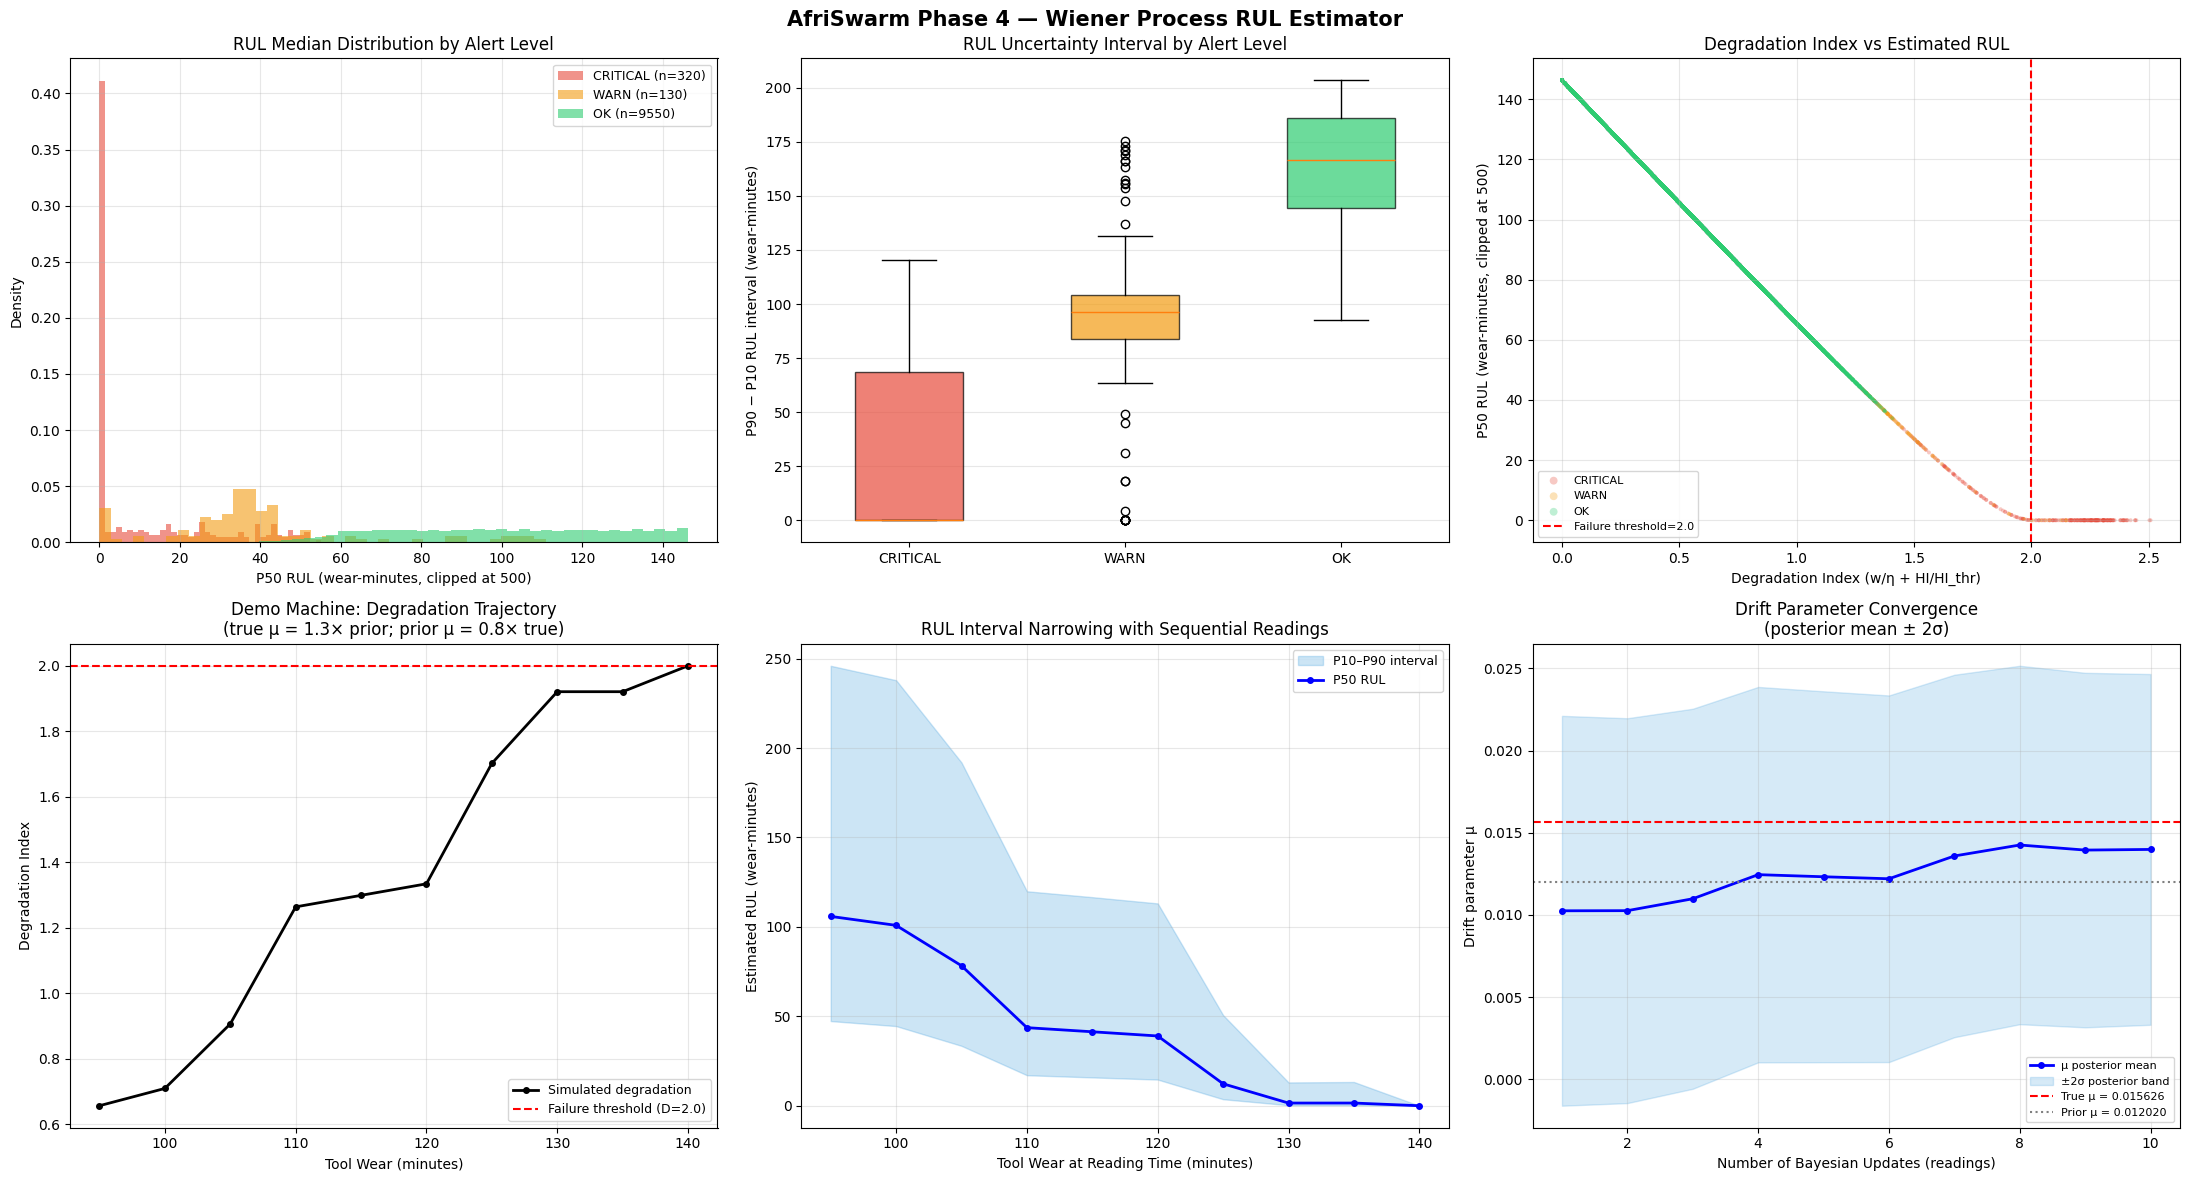


Phase 4 dashboard saved.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('AfriSwarm Phase 4 — Wiener Process RUL Estimator',
             fontsize=15, fontweight='bold')

colors_alert = {'CRITICAL': '#e74c3c', 'WARN': '#f39c12', 'OK': '#2ecc71'}

# (a) RUL P50 distribution by alert level
ax = axes[0, 0]
for level, color in colors_alert.items():
    sub = phase4_merged[phase4_merged['alert_level'] == level]['rul_p50']
    if len(sub) > 0:
        ax.hist(sub.clip(upper=500), bins=40, alpha=0.6,
                color=color, label=f'{level} (n={len(sub)})', density=True)
ax.set_xlabel('P50 RUL (wear-minutes, clipped at 500)')
ax.set_ylabel('Density')
ax.set_title('RUL Median Distribution by Alert Level')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (b) Uncertainty band: P90 − P10 range per alert level (box plot)
ax = axes[0, 1]
for i, (level, color) in enumerate(colors_alert.items()):
    sub = phase4_merged[phase4_merged['alert_level'] == level]
    if len(sub) > 0:
        uncertainty = (sub['rul_p90'] - sub['rul_p10']).clip(upper=500)
        bp = ax.boxplot(uncertainty, positions=[i], widths=0.5,
                        patch_artist=True, notch=False)
        bp['boxes'][0].set_facecolor(color)
        bp['boxes'][0].set_alpha(0.7)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(list(colors_alert.keys()))
ax.set_ylabel('P90 − P10 RUL interval (wear-minutes)')
ax.set_title('RUL Uncertainty Interval by Alert Level')
ax.grid(True, alpha=0.3, axis='y')

# (c) Degradation index vs P50 RUL scatter
ax = axes[0, 2]
for level, color in colors_alert.items():
    sub = phase4_merged[phase4_merged['alert_level'] == level]
    d_idx = degradation_index(sub['tool_wear'], sub['hi'], eta_w)
    ax.scatter(d_idx, sub['rul_p50'].clip(upper=500),
               c=color, alpha=0.3, s=8, edgecolors='none', label=level)
ax.axvline(D_THRESHOLD, color='red', linestyle='--', lw=1.5,
           label=f'Failure threshold={D_THRESHOLD}')
ax.set_xlabel('Degradation Index (w/η + HI/HI_thr)')
ax.set_ylabel('P50 RUL (wear-minutes, clipped at 500)')
ax.set_title('Degradation Index vs Estimated RUL')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True, alpha=0.3)

# (d) Bayesian update demo: degradation trajectory
ax = axes[1, 0]
if len(demo_snap_df) > 0:
    ax.plot(demo_snap_df['wear'], demo_snap_df['hi'],
            'k-o', ms=4, lw=2, label='Simulated degradation')
    ax.axhline(D_THRESHOLD, color='red', linestyle='--', lw=1.5,
               label=f'Failure threshold (D={D_THRESHOLD})')
    ax.set_xlabel('Tool Wear (minutes)')
    ax.set_ylabel('Degradation Index')
    ax.set_title(f'Demo Machine: Degradation Trajectory\n'
                 f'(true μ = 1.3× prior; prior μ = 0.8× true)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# (e) Bayesian update demo: RUL intervals narrowing
ax = axes[1, 1]
if len(demo_snap_df) > 0:
    ax.fill_between(demo_snap_df['wear'],
                    demo_snap_df['rul_p10'],
                    demo_snap_df['rul_p90'],
                    alpha=0.25, color='#3498db', label='P10–P90 interval')
    ax.plot(demo_snap_df['wear'], demo_snap_df['rul_p50'],
            'b-o', ms=4, lw=2, label='P50 RUL')
    ax.set_xlabel('Tool Wear at Reading Time (minutes)')
    ax.set_ylabel('Estimated RUL (wear-minutes)')
    ax.set_title('RUL Interval Narrowing with Sequential Readings')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# (f) Bayesian update demo: μ convergence
ax = axes[1, 2]
if len(demo_snap_df) > 0:
    ax.plot(demo_snap_df['n_updates'], demo_snap_df['mu_posterior'],
            'b-o', ms=4, lw=2, label='μ posterior mean')
    ax.fill_between(
        demo_snap_df['n_updates'],
        demo_snap_df['mu_posterior'] - 2 * demo_snap_df['tau_posterior'],
        demo_snap_df['mu_posterior'] + 2 * demo_snap_df['tau_posterior'],
        alpha=0.2, color='#3498db', label='±2σ posterior band'
    )
    ax.axhline(MU_TRUE, color='red', linestyle='--', lw=1.5,
               label=f'True μ = {MU_TRUE:.6f}')
    ax.axhline(MU_PRIOR, color='grey', linestyle=':', lw=1.5,
               label=f'Prior μ = {MU_PRIOR:.6f}')
    ax.set_xlabel('Number of Bayesian Updates (readings)')
    ax.set_ylabel('Drift parameter μ')
    ax.set_title('Drift Parameter Convergence\n(posterior mean ± 2σ)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE}/results/phase4/phase4_rul_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'\nPhase 4 dashboard saved.')

## CELL 26 — Final Summary (All Phases)

In [ ]:
print('\n' + '=' * 60)
print('AFRISWARM COMPLETE VALIDATION SUMMARY — PHASES 1–4')
print('=' * 60)

print(f'\nPhase 1 — XGBoost Snapshot Classifier:')
print(f'  F1 score (5-fold OOF): {mean_f1_ai4i:.4f}  '
      f'{"PASS" if mean_f1_ai4i >= 0.85 else "FAIL"} (target ≥ 0.85)')
print(f'  Optimal threshold    : {best_thresh_ai4i:.2f}')

print(f'\nPhase 2A — Weibull Survival Fit:')
print(f'  β = {beta_w:.4f}  η = {eta_w:.2f}')
print(f'  β > 1 confirms increasing hazard (wear-out failure regime)')

print(f'\nPhase 2B — Generative Model (Weibull-VAE):')
print(f'  Fréchet Distance: {fd_ai4i:.4f}  '
      f'{"PASS" if fd_ai4i <= 0.15 else "REVIEW"} (target ≤ 0.15)')
print(f'  TSTR F1: {f1_tstr_ai4i:.3f}  Real F1: {f1_real_ai4i:.3f}  '
      f'Gap: {abs(f1_real_ai4i - f1_tstr_ai4i):.3f}')

print(f'\nPhase 2C — CVAE Cold-Start Recovery:')
k0_rows = cvae_df[cvae_df['k_failures'] == 0]
k0_tuned_mean = k0_rows['f1_cvae_tuned'].mean()
print(f'  F1 at k=0 failures (tuned): {k0_tuned_mean:.3f}')
print(f'  F1 plateau reached by k=2 — cold start solved')

print(f'\nPhase 3 — Health Indicator & Prognosis:')
print(f'  Prognostic AUC-ROC (personalised HI×P60): {auc_personalised:.4f}')
print(f'  Avg Precision (personalised):              {ap_personalised:.4f}')
alert_counts_p4 = phase4_merged['alert_level'].value_counts()
for level in ['CRITICAL', 'WARN', 'OK']:
    n   = alert_counts_p4.get(level, 0)
    pct = 100 * n / len(phase4_merged)
    print(f'  {level:8s}: {n:5d} machines ({pct:.1f}%)')

print(f'\nPhase 4 — Wiener Process RUL Estimator:')
print(f'  Derived from Weibull — no additional data required')
print(f'  μ_prior (population drift) = {MU_PRIOR:.8f} d-units/wear-min')
print(f'  σ (diffusion)              = {SIGMA:.8f}')
print(f'  E[T] from Weibull          = {E_T_weibull:.1f} wear-minutes')
print(f'  All {len(machine_states)} machines assigned RUL distributions (prior-dominated)')
print(f'  Bayesian update ready: regime transitions at 5 and 20 readings')
print(f'\n  RUL summary across all machines:')
for level in ['CRITICAL', 'WARN', 'OK']:
    sub = phase4_merged[phase4_merged['alert_level'] == level]
    if len(sub) > 0:
        print(f'  {level:8s}: P50 mean={sub["rul_p50"].mean():.1f} wmin  '
              f'P10 mean={sub["rul_p10"].mean():.1f} wmin')

print(f'\nOutput files — All Phases:')
for root, dirs, files in os.walk(f'{BASE}/results'):
    for f in files:
        print(f'  {os.path.join(root, f).replace(BASE, "")}')


AFRISWARM COMPLETE VALIDATION SUMMARY — PHASES 1–4

Phase 1 — XGBoost Snapshot Classifier:
  F1 score (5-fold OOF): 0.8599  PASS (target ≥ 0.85)
  Optimal threshold    : 0.93

Phase 2A — Weibull Survival Fit:
  β = 1.9744  η = 187.70
  β > 1 confirms increasing hazard (wear-out failure regime)

Phase 2B — Generative Model (Weibull-VAE):
  Fréchet Distance: 0.0688  PASS (target ≤ 0.15)
  TSTR F1: 0.684  Real F1: 0.809  Gap: 0.125

Phase 2C — CVAE Cold-Start Recovery:
  F1 at k=0 failures (tuned): 0.735
  F1 plateau reached by k=2 — cold start solved

Phase 3 — Health Indicator & Prognosis:
  Prognostic AUC-ROC (personalised HI×P60): 0.9995
  Avg Precision (personalised):              0.9872
  CRITICAL:   320 machines (3.2%)
  WARN    :   130 machines (1.3%)
  OK      :  9550 machines (95.5%)

Phase 4 — Wiener Process RUL Estimator:
  Derived from Weibull — no additional data required
  μ_prior (population drift) = 0.01201993 d-units/wear-min
  σ (diffusion)              = 0.08199129
  

## CELL 27 — Download Results as ZIP

In [ ]:
import shutil
from google.colab import files
shutil.make_archive('/content/afriswarm_ai4i_results', 'zip', BASE)
files.download('/content/afriswarm_ai4i_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>